In [1]:
%load_ext autoreload
%autoreload 2

import os
import jax
import matplotlib.pyplot as plt

os.chdir("..")
import numpy as np
from flax import serialization

from src.c3po.analysis.analysis import C3poAnalysis
from src.c3po.model.model import C3PO

# analysis=C3poAnalysis(None, None, None)

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(


# Loading

## Load in data objects

In [2]:
import numpy as np
from scipy.io import loadmat

data_name = "/stelmo/sam/c3po_results/moserdata.mat"
# data_name = "/stelmo/sam/c3po_datasets/moser_mec_25843_2_openfield.mat"


data = loadmat(
    data_name
    # "/stelmo/sam/c3po_datasets/moser_mec_25843_2_openfield.mat"
)  # in the downloadable Vollan archive, this is 27765_2.mat  (potentially can do this with any other data file)


def mat_fields(s):
    """Return field names for a MATLAB struct (np.void or structured ndarray)."""
    if isinstance(s, np.ndarray) and s.dtype.names:
        return s.dtype.names
    if isinstance(s, np.void) and s.dtype.names:
        return s.dtype.names
    raise TypeError("Not a MATLAB struct (np.void/structured ndarray).")


# The 'Dsession' key gives the main struct
Dsession = data["Dsession"]

t = Dsession["t"][0, 0].flatten()  # times
x = Dsession["x"][0, 0].flatten()  # x positions
y = Dsession["y"][0, 0].flatten()  # y positions
speed = Dsession["speed"][0, 0].flatten()  #
thetaphase = Dsession["theta"][0, 0].flatten()  #
units = Dsession["units"][0, 0].flatten()  # unit data (more parsing below)
unit_cluster_id = units["mec"][0]["acorrCluId"][:]

head_dir = Dsession["hd"][0, 0].flatten()
hd_cont = np.unwrap(head_dir)
ang_vel = np.gradient(hd_cont, np.median(np.diff(t)))
ind_jump = np.where(np.diff(t) > 0.1)[0]
ang_vel[ind_jump] = 0
ang_vel[ind_jump + 1] = 0

In [3]:
t_spikes = np.arange(t[0], t[-1], 0.002)
spikes = []
for uu in range(len(units["mec"][0]["spikeTimes"])):
    spikes.append(units["mec"][0]["spikeTimes"][uu][0].flatten())

len(spikes)


from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

smoothing_window = 0.02  # in seconds
smoothing_window = 0.003  # in seconds
dt = t_spikes[1] - t_spikes[0]
smoothing_window_bins = int(smoothing_window / dt)
rates = []

for uu in tqdm(range(len(spikes))):
    rate, _ = np.histogram(
        spikes[uu], bins=np.concatenate([t_spikes, [t_spikes[-1] + (dt)]])
    )
    # rate = np.convolve(
    #     rate,
    #     np.ones(smoothing_window_bins) / smoothing_window_bins,
    #     mode="same",
    # )
    rate = gaussian_filter1d(
        rate[:, None].astype("float"),
        sigma=smoothing_window_bins,
        axis=0,
        mode="nearest",
    )

    rates.append(rate / (t[1] - t[0]))  # in Hz
rates = np.squeeze(rates).T

100%|██████████| 460/460 [00:29<00:00, 15.50it/s]


In [4]:
# plt.hist(np.log10(np.diff(t)))
# plt.yscale("log")
# np.median(np.diff(t))
dt = np.diff(t)

ind_valid = (dt < 0.02).astype(int)  # only use intervals with dt < 20 ms
starts = np.where(np.diff(ind_valid) == 1)[0] + 1
ends = np.where(np.diff(ind_valid) == -1)[0] + 1
if ind_valid[0]:
    starts = np.insert(starts, 0, 0)
if ind_valid[-1]:
    ends = np.append(ends, len(ind_valid))
valid_intervals = [[t[s], t[e]] for s, e in zip(starts, ends)]

## Load in encoding results

In [5]:
from src.c3po.tables.dev_tables import C3POStorage
import matplotlib.pyplot as plt

C3POStorage()  # .alter()
model_name = "mec_wavenet_25843_all_cells"
model_name = "mec_wavenet_all_cells"


# model_name = "moser_mec_29502_1_openfield_wavenet_all_cells"
# model_name = f"mec_{data_name.split('/')[-1].split('.')[0]}_jan2026"

# key = {"model_name": "mec_wavenet_all_cells"}
key = dict(model_name=model_name)

analysis = (C3POStorage & key).fetch_analysis_object()

analysis.load_embedding(f"/stelmo/sam/c3po_results/{key['model_name']}_embedding.npz")

diff_t = np.diff(analysis.t)
bad_diff = np.where(diff_t > 0.1)[0] + 1
bad_diff = np.concatenate([[0], bad_diff, np.array([len(analysis.t)])])
no_gap_intervals = []
for i in range(len(bad_diff) - 1):
    no_gap_intervals.append((analysis.t[bad_diff[i]], analysis.t[bad_diff[i + 1] - 1]))
no_gap_intervals = np.array(no_gap_intervals)[:-7]

t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.fit_context_pca(fit_intervals=no_gap_intervals)

# Just showing how to access the variables
# t = analysis.t
z = analysis.z
c = analysis.c
c_pca = analysis.c_pca
t_interp = analysis.t_interp
c_interp = analysis.c_interp
c_pca_interp = analysis.c_pca_interp

entry = (C3POStorage & key).fetch1()
latent_dim = entry["latent_dim"]
context_dim = entry["context_dim"]

# define figure directory
from src.c3po.analysis.analysis import figure_directory
from pathlib import Path

figure_directory = Path(figure_directory)
figure_folder = figure_directory / "Fig3" / "mec_open_field" / model_name
os.makedirs(figure_folder, exist_ok=True)
plt.rcParams["svg.fonttype"] = "none"  # to get editable text in Illustrator

[2026-07-31 07:26:17,878][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306


# Analysis

In [6]:
import matplotlib.pyplot as plt
from spyglass.common.common_interval import Interval

### Plot example

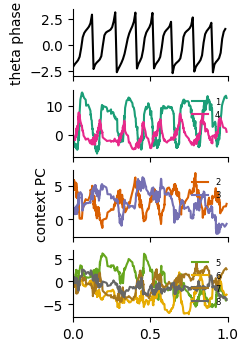

In [317]:
fig, ax = plt.subplots(nrows=4, sharex=True, height_ratios=[1, 1, 1, 1], figsize=(2, 4))
ind = slice(11000, 12300)
ind = slice(14500, 15500)

t0 = analysis.t[ind][0]

plot_interval = Interval(np.array([[analysis.t[ind][0], analysis.t[ind][-1]]]))
behavior_inds = plot_interval.contains(t, as_indices=True)
ax[0].plot(t[behavior_inds] - t0, thetaphase[behavior_inds], c="k")
# ax[1].plot(t[behavior_inds], head_dir[behavior_inds], c="k")

# ax[2].plot(analysis.t[ind], analysis.c_pca[ind, :6])
pc_set = [[0, 3], [1, 2], [4, 5, 6, 7]]

for i, pcs in enumerate(pc_set):
    for j in pcs:
        color = plt.cm.Dark2(j / 8)
        ax[i + 1].plot(
            analysis.t[ind] - t0, analysis.c_pca[ind, j], label=f"{j+1}", color=color
        )
    ax[i + 1].legend(fontsize=6, loc="upper right", frameon=False)

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
ax[0].set_ylabel("theta phase")
ax[2].set_ylabel("context PC")

plt.xlim(0, 1)

fig.savefig(figure_folder / "time_traces.svg")

# Binned context, mult features

Text(0.5, 0, 'Head direction \n(rad)')

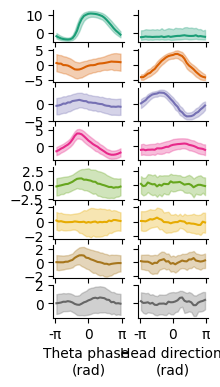

In [319]:
fig, ax_array = plt.subplots(
    nrows=8, ncols=2, sharex=True, sharey="row", figsize=(2, 4)
)


context_theta, theta_bins = analysis.bin_context_by_feature(
    thetaphase,
    t,
    bins=np.linspace(-np.pi, np.pi, 30),
    pca=True,
)
context_hd, hd_bins = analysis.bin_context_by_feature(
    head_dir,
    t,
    bins=np.linspace(-np.pi, np.pi, 30),
    pca=True,
)


for ax, context_binned, bins in zip(
    ax_array.T, [context_theta, context_hd], [theta_bins, hd_bins]
):

    mid = np.array([np.nanmedian(c_, axis=0) for c_ in context_binned])
    lo = np.array([np.nanpercentile(c_, 25, axis=0) for c_ in context_binned])
    hi = np.array([np.nanpercentile(c_, 75, axis=0) for c_ in context_binned])
    # for dat, loc in zip(context_binned, bins):

    loc_plot = bins[:-1] + np.diff(bins) / 2
    for i, a in enumerate(ax):
        color = "cornflowerblue"
        color = plt.cm.Dark2(i / 8)

        a.plot(loc_plot, mid[:, i], color=color)
        a.fill_between(loc_plot, lo[:, i], hi[:, i], color=color, alpha=0.3)
        a.spines[["right", "top"]].set_visible(False)

# for i, a in enumerate(ax_array[:,0]):
#     a.set_ylabel(f"Component {i+1}")

for a in ax_array[-1, :]:
    a.set_xticks([-np.pi, 0, np.pi])
    a.set_xticklabels(["-π", "0", "π"])

ax_array[-1, 0].set_xlabel("Theta phase \n(rad)")
ax_array[-1, 1].set_xlabel("Head direction \n(rad)")

# plt.xlabel("Theta phase (rad)")

# fig.savefig(figure_folder / "context_vs_phases.svg")

### Average context value vs phase

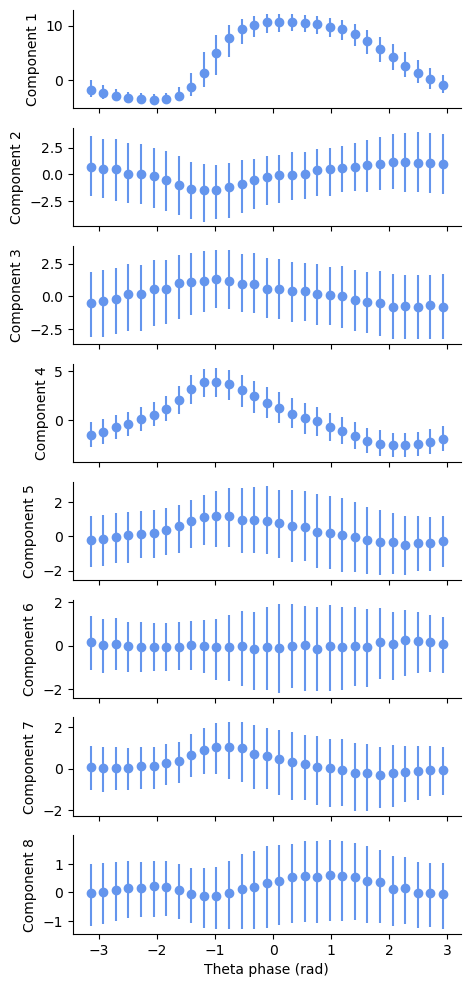

In [ ]:
context_binned, bins = analysis.bin_context_by_feature(
    thetaphase,
    t,
    bins=np.linspace(-np.pi, np.pi, 30),
    pca=True,
    # valid_intervals=no_gap_intervals,
    # interpolated=True,
)

fig, ax = plt.subplots(nrows=8, sharex=True, figsize=(5, 12))
for dat, loc in zip(context_binned, bins):
    for i, a in enumerate(ax):
        color = "cornflowerblue"
        a.scatter(loc, np.nanmedian(dat[:, i]), c=color)
        a.vlines(
            loc,
            np.nanpercentile(dat[:, i], 25),
            np.nanpercentile(dat[:, i], 75),
            color=color,
        )
        a.spines[["right", "top"]].set_visible(False)
for i, a in enumerate(ax):
    a.set_ylabel(f"Component {i+1}")
plt.xlabel("Theta phase (rad)")

fig.savefig(figure_folder / "context_vs_theta_phase.svg")

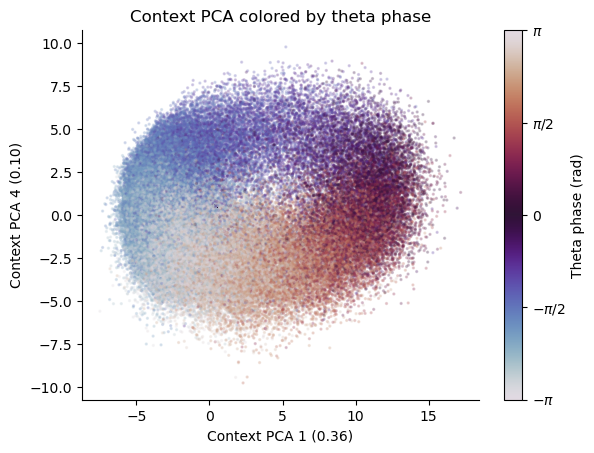

In [220]:
plot_dims = [0, 3]
# plot_dims = [0, 1]

subset = slice(None, None, 10)

fig = plt.figure()
ind_phase = np.digitize(analysis.t, t)
# ind_data = ind_data[subset]
sc = plt.scatter(
    c_pca[subset][:, plot_dims[0]],
    c_pca[subset][:, plot_dims[1]],
    s=2,
    alpha=0.2,
    c=thetaphase[ind_phase[subset] - 1],
    cmap="twilight",
    rasterized=True,
)
cbar = plt.colorbar(sc, label="Theta phase (rad)")
cbar.solids.set_alpha(1)
cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
plt.xlabel(
    f"Context PCA {plot_dims[0]+1} ({analysis.pca.explained_variance_ratio_[plot_dims[0]]:.2f})"
)
plt.ylabel(
    f"Context PCA {plot_dims[1]+1} ({analysis.pca.explained_variance_ratio_[plot_dims[1]]:.2f})"
)
plt.title("Context PCA colored by theta phase")
fig.gca().spines[["top", "right"]].set_visible(False)

fig.savefig(figure_folder / "context_pca_theta_phase_scatter.svg")

### Context value vs. head_dir

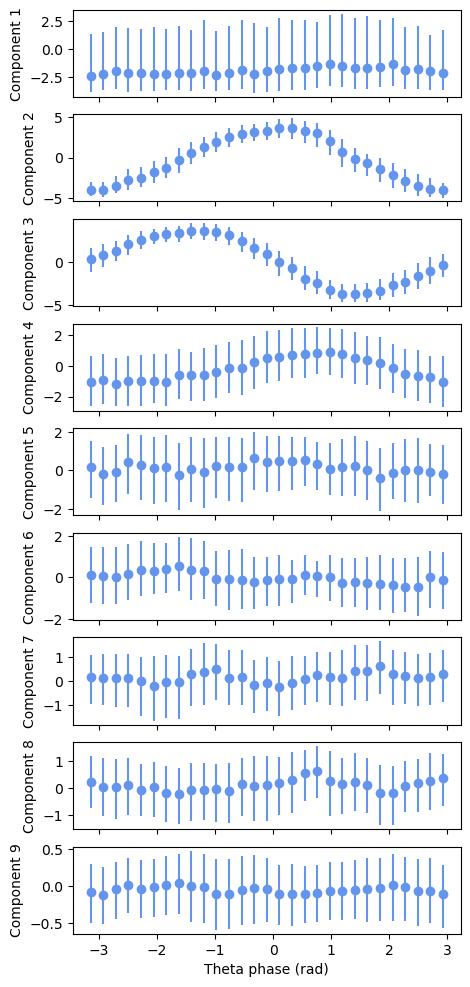

In [19]:
context_binned, bins = analysis.bin_context_by_feature(
    head_dir,
    t,
    bins=np.linspace(-np.pi, np.pi, 30),
    pca=True,
    valid_intervals=no_gap_intervals,
    # interpolated=True,
)

fig, ax = plt.subplots(nrows=9, sharex=True, figsize=(5, 12))
for dat, loc in zip(context_binned, bins):
    for i, a in enumerate(ax):
        color = "cornflowerblue"
        a.scatter(loc, np.nanmedian(dat[:, i]), c=color)
        a.vlines(
            loc,
            np.nanpercentile(dat[:, i], 25),
            np.nanpercentile(dat[:, i], 75),
            color=color,
        )
for i, a in enumerate(ax):
    a.set_ylabel(f"Component {i+1}")
plt.xlabel("Theta phase (rad)")

fig.savefig(figure_folder / "context_vs_head_direction.svg")

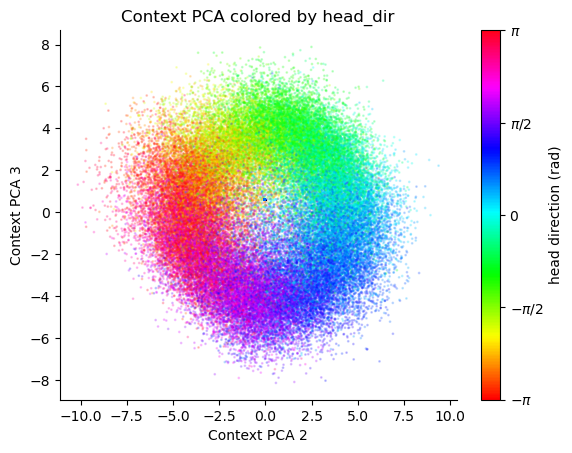

In [21]:
plot_dims = [1, 2]
# plot_dims = [2, 3]
subset = slice(None, None, 20)

fig = plt.figure()
ind_dir = np.digitize(analysis.t, t)
# ind_data = ind_data[subset]
sc = plt.scatter(
    c_pca[subset][:, plot_dims[0]],
    c_pca[subset][:, plot_dims[1]],
    s=1,
    alpha=0.2,
    c=head_dir[ind_dir[subset] - 1],
    cmap="hsv",
    rasterized=True,
)
cbar = plt.colorbar(label="head direction (rad)")
cbar.solids.set_alpha(1)
cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
plt.xlabel(f"Context PCA {plot_dims[0]+1}")
plt.ylabel(f"Context PCA {plot_dims[1]+1}")
plt.title("Context PCA colored by head_dir")
fig.gca().spines[["top", "right"]].set_visible(False)

fig.savefig(figure_folder / "context_pca_head_dir_scatter.svg")

### Average Context values vs 2d position

In [31]:
t.min(), analysis.t.min(), analysis.t.max()

(10624.39, 10624.385133333333, 12925.064542487768)

Jittering features and re-binning context: 100%|██████████| 30/30 [01:13<00:00,  2.44s/it]


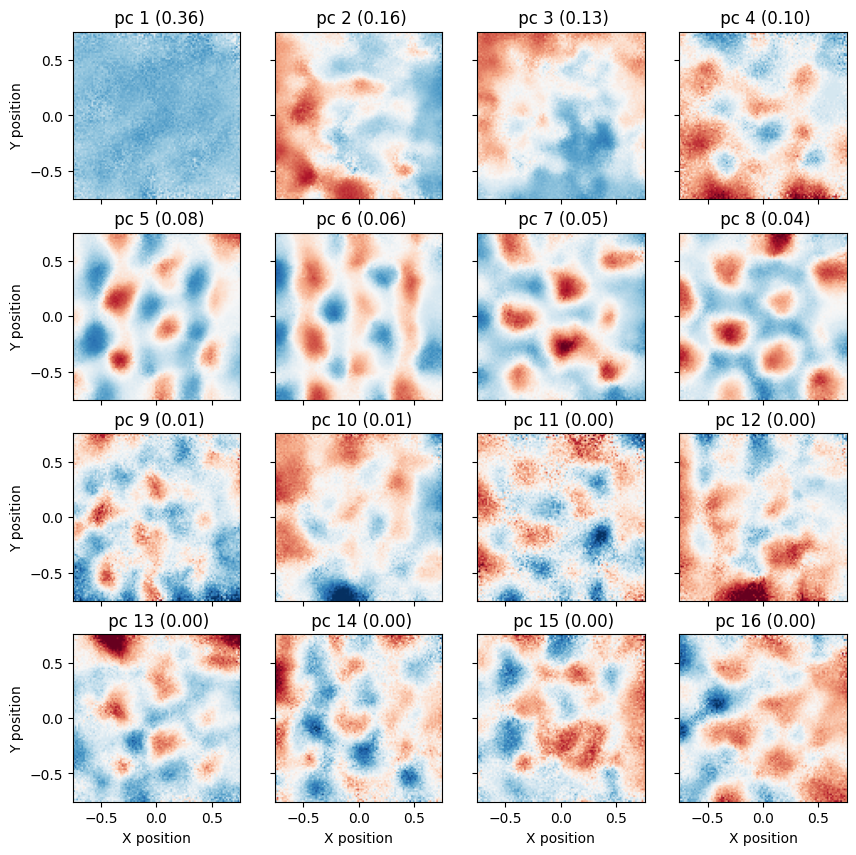

In [320]:
bins = np.linspace(np.min(x), np.max(x), 100)
c_binned, bins_x, bins_y = analysis.bin_context_by_feature_2d(
    x,
    t,
    y,
    t,
    pca=True,
    bins_1=bins,
    bins_2=bins,
    valid_intervals=no_gap_intervals,
    interpolated=True,
    jitter_feature_sigma=0.05,
    jitter_feature_n=30,
    # interpolated=False,
)
h = np.zeros(
    (bins_x.size, bins_y.size, analysis.context_dim),
)

for i in range(h.shape[0]):
    for j in range(h.shape[1]):
        if len(c_binned[i][j]) == 0:
            h[i, j] = np.nan
        h[i, j] = np.nanmedian(c_binned[i][j], axis=0)

fig, ax = plt.subplots(
    nrows=min(4, analysis.latent_dim),
    ncols=4,
    figsize=(10, 10),
    sharex=True,
    sharey=True,
)
for i, a in enumerate(ax.ravel()):
    if i >= analysis.context_dim:
        break
    c_rng = np.nanmax(np.abs(h[:, :, i])) * 0.75
    # c_rng =
    c_rng = np.nanpercentile(np.abs(h[:, :, i]), 90) * 2
    a.imshow(
        h[:, :, i].T,
        aspect=1,
        origin="lower",
        extent=(bins_x[0], bins_x[-1], bins_y[0], bins_y[-1]),
        cmap="RdBu",
        clim=(-c_rng, c_rng),
    )
    # a.set_title(f"Latent dimension {i+1}")
    # a.set_xlabel("X position (cm)")
    a.set_title(f" pc {i+1} ({analysis.pca.explained_variance_ratio_[i]:.2f})")

for a in ax[:, 0]:
    a.set_ylabel("Y position")


for a in ax[-1, :]:
    a.set_xlabel("X position")

# if bins.size < 100:
#     fig.savefig(figure_folder / "context_vs_xy_position.svg")

In [220]:
%debug

> /home/sambray/Documents/c3po/src/c3po/analysis/analysis.py(605)bin_context_by_feature_2d()
    603                             context_binned[b1][b2] = context_binned_i[b1][b2]
    604                         else:
--> 605                             context_binned[b1][b2] = np.concatenate(
    606                                 [context_binned[b1][b2], context_binned_i[b1][b2]]
    607                             )

[]
[]


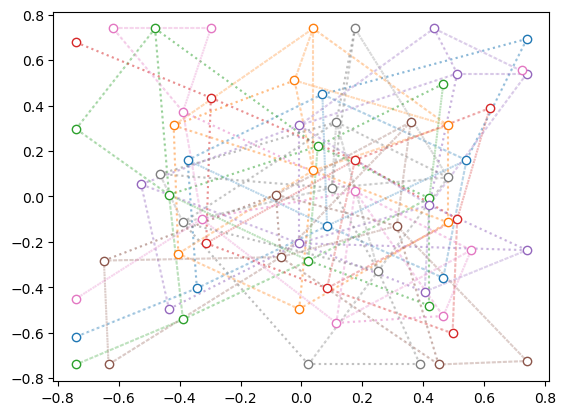

In [ ]:
def find_peaks_2d(data, width=3):
    """
    Finds all local maxima in a 2D numpy array.
    A point is a peak if it is strictly greater than all 8 neighbors.
    """
    peaks = []
    rows, cols = data.shape
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            center = data[i, j]
            if np.isnan(center):
                continue  # skip NaN values
            # Check all 8 neighbors
            neighbors = data[
                max(0, i - width) : min(rows, i + width + 1),
                max(0, j - width) : min(cols, j + width + 1),
            ].flatten()

            if center >= np.nanmax(neighbors):
                peaks.append((i, j, center))
    return peaks


# find_peaks_2d(h[:,:,5])

# plt.imshow(h[:,:,5].T, aspect=1, origin="lower", extent=(bins_x[0], bins_x[-1], bins_y[0], bins_y[-1]), cmap="RdBu")
# for peak in find_peaks_2d(h[:,:,5]):
#     plt.plot(bins_x[peak[0]], bins_y[peak[1]], 'kx')

distances = []
peak_width = h.shape[0] // 10
for i in range(4, 12):

    # color = plt.cm.Dark2(i / 8)
    color = f"C{i-4}"
    pos_peaks = find_peaks_2d(h[:, :, i], width=peak_width)
    neg_peaks = find_peaks_2d(-h[:, :, i], width=peak_width)

    # for peak in pos_peaks:
    #     plt.scatter(bins_x[peak[0]], bins_y[peak[1]], c=color, marker='x')
    # for peak in neg_peaks:
    #     plt.scatter(
    #         bins_x[peak[0]],
    #         bins_y[peak[1]],
    #         edgecolor=color,
    #         marker="o",
    #         facecolor="white",
    #     )

    peak_set = neg_peaks
    for peak in peak_set:
        plt.scatter(
            bins_x[peak[0]],
            bins_y[peak[1]],
            edgecolor=color,
            marker="o",
            facecolor="white",
        )

    distances_i = []
    for peak in peak_set:
        for peak2 in peak_set:
            dist = np.sqrt(
                (bins_x[peak[0]] - bins_x[peak2[0]]) ** 2
                + (bins_y[peak[1]] - bins_y[peak2[1]]) ** 2
            )
            distances_i.append(dist)
            if dist > 0.75:
                continue
            if peak == peak2:
                continue
            plt.plot(
                [bins_x[peak[0]], bins_x[peak2[0]]],
                [bins_y[peak[1]], bins_y[peak2[1]]],
                alpha=0.3,
                color=color,
                zorder=-1,
                ls=":",
            )

    distances.append(distances_i)

/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


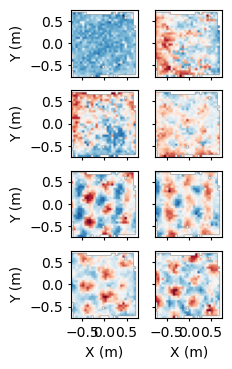

In [ ]:
bins = np.linspace(np.min(x), np.max(x), 30)
c_binned, bins_x, bins_y = analysis.bin_context_by_feature_2d(
    x,
    t,
    y,
    t,
    pca=True,
    bins_1=bins,
    bins_2=bins,
    valid_intervals=no_gap_intervals,
    interpolated=True,
)
h = np.zeros(
    (bins_x.size, bins_y.size, analysis.context_dim),
)

for i in range(h.shape[0]):
    for j in range(h.shape[1]):
        if len(c_binned[i][j]) == 0:
            h[i, j] = np.nan
        h[i, j] = np.nanmedian(c_binned[i][j], axis=0)

fig, ax = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(2, 4),
    sharex=True,
    sharey=True,
)
for i, a in enumerate(ax.ravel()):
    if i >= analysis.context_dim:
        break
    c_rng = np.nanmax(np.abs(h[:, :, i])) * 1
    # c_rng = np.nanmedian(np.abs(h[:, :, i])) * 2
    a.imshow(
        h[:, :, i].T,
        aspect=1,
        origin="lower",
        extent=(bins_x[0], bins_x[-1], bins_y[0], bins_y[-1]),
        cmap="RdBu",
        clim=(-c_rng, c_rng),
    )
    # a.set_title(f"Latent dimension {i+1}")
    # a.set_xlabel("X position (cm)")
    # a.set_title(f" pc {i+1} ({analysis.pca.explained_variance_ratio_[i]:.2f})")

for a in ax[:, 0]:
    a.set_ylabel("Y (m)")


for a in ax[-1, :]:
    a.set_xlabel("X (m)")

for a in ax.ravel():
    a.tick_params(size=2)

if bins.size < 100:
    fig.savefig(figure_folder / "context_vs_xy_position.svg")

## test autocorrelation function

In [230]:
from __future__ import annotations
import numpy as np
from numpy.typing import NDArray
from typing import Tuple


def radial_autocorrelation(
    arr: NDArray[np.float64],
    *,
    nbins: int | None = None,
) -> Tuple[NDArray[np.float64], NDArray[np.float64]]:
    """
    Compute the radial autocorrelation of a 2D array.

    Parameters
    ----------
    arr
        Input 2D array of values with shape (ny, nx).
    nbins
        Number of radial bins (if None, uses min(ny, nx) // 2).

    Returns
    -------
    r
        1D array of distances (bin centers).
    acorr
        Radially averaged autocorrelation values.
    """
    # FFT of input and compute autocorrelation in 2D
    f = np.fft.fft2(arr - np.mean(arr))
    power = np.abs(f) ** 2
    acorr2d = np.fft.ifft2(power).real

    # Shift zero lag to center
    acorr2d = np.fft.fftshift(acorr2d)

    ny, nx = arr.shape
    y = np.arange(-ny // 2, ny // 2)
    x = np.arange(-nx // 2, nx // 2)
    X, Y = np.meshgrid(x, y)

    # distance map
    dist = np.sqrt(X**2 + Y**2)

    if nbins is None:
        nbins = min(nx, ny) // 2

    # radial bin edges
    r_max = np.min([nx, ny]) / 2
    edges = np.linspace(0, r_max, nbins + 1)
    bin_centers = (edges[:-1] + edges[1:]) / 2

    acorr = np.zeros(nbins, dtype=np.float64)
    counts = np.zeros(nbins, dtype=np.int64)

    # bin by distance
    for i in range(nbins):
        mask = (dist >= edges[i]) & (dist < edges[i + 1])
        acorr[i] = acorr2d[mask].sum()
        counts[i] = mask.sum()

    # normalize by counts
    acorr /= counts

    return bin_centers, acorr

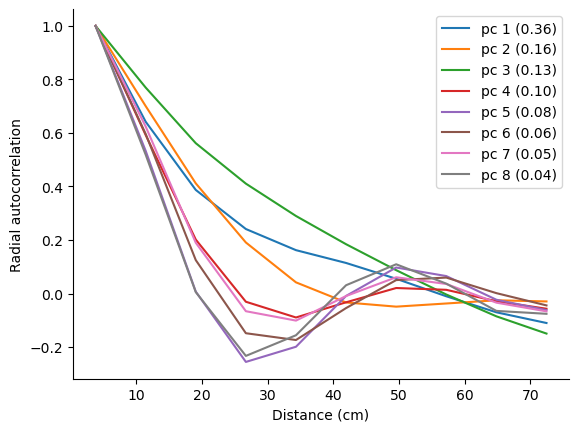

In [ ]:
import numpy as np
from scipy.signal import correlate2d

fig = plt.figure()
ax = fig.add_subplot(111)
# for i in range(h.shape[-1]):
for i in np.arange(0, 8):
    # for i in range(12, 16):
    val = h[:, :, i].copy()

    val[np.isnan(val)] = np.nanmean(val)
    dist, acorr = radial_autocorrelation(val, nbins=10)
    acorr = acorr / np.max(acorr)
    plt.plot(
        dist * np.mean(np.diff(bins)) * 100,
        acorr,
        label=f"pc {i+1} ({analysis.pca.explained_variance_ratio_[i]:.2f})",
    )

plt.xlabel("Distance (cm)")
plt.ylabel("Radial autocorrelation")
plt.legend(loc="upper right")
ax.spines[["right", "top"]].set_visible(False)

# fig.savefig(figure_folder / "context_xy_radial_autocorr.svg")

In [212]:
# # make contour plots

# import matplotlib.pyplot as plt
# import numpy as np

# import matplotlib.cm as cm


# X, Y = np.meshgrid(bins_x[:], bins_y[:])


# val = h[:, :, 4].T
# val[np.isnan(val)] = np.nanmean(val)
# fig, ax = plt.subplots()
# CS = ax.contour(X, Y, val, levels=1, cmap="plasma")
# # ax.clabel(CS, fontsize=10)

# val = h[:, :, 5].T
# val[np.isnan(val)] = np.nanmean(val)
# CS = ax.contour(X, Y, val, levels=1, cmap="PiYG")
# # ax.clabel(CS, fontsize=10)
# # ax.set_title("Simplest default with labels")

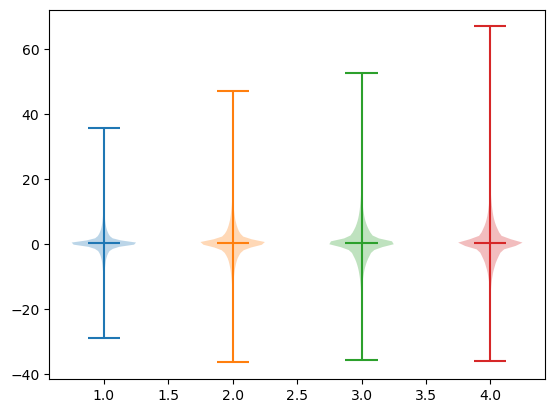

In [ ]:
def position_orthogonality(h):
    h = h.copy()
    h = h.reshape(-1, h.shape[-1])
    vals = []
    for i in range(h.shape[0] // 2):
        v1 = np.roll(h, shift=i, axis=0)
        corr = np.sum(h * v1, axis=1)
        vals.extend(corr.tolist())
    return np.array(vals)


val = h.copy()
for i in range(val.shape[-1]):
    val[:, :, i][np.isnan(val[:, :, i])] = np.nanmean(val[:, :, i])

for i in range(1, 5):
    plt.violinplot(
        position_orthogonality(val[:, :, 4 : 4 + i]), positions=[i], showmeans=True
    )

# Power Spectrums

In [214]:
f, mid, lo, hi = analysis.power_spectrum(
    intervals=valid_intervals, window_size=4000, nfft=100000
)

(0.0, 20.0)

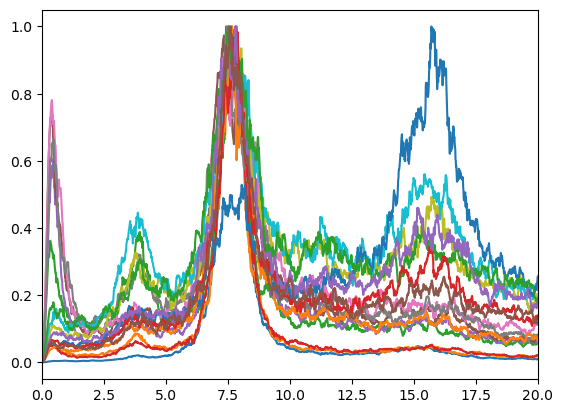

In [129]:
y_plot = mid.T * f[:, None]
y_plot = y_plot / np.max(y_plot, axis=0)

plt.plot(f, y_plot)
plt.xlim(0, 20)
# plt.xlim(6,9)
# plt.xscale('log')
# plt.yscale('log')

IndexError: index 3 is out of bounds for axis 1 with size 1

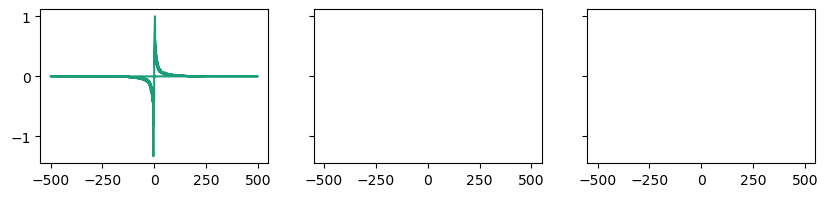

In [213]:
fig, ax = plt.subplots(ncols=3, sharex=True, sharey=True, figsize=(10, 2))

dim_groups = {
    "theta": [0, 3],
    "head direction": [1, 2],
    "grid": [4, 5, 6, 7],
}
y_plot = mid.T * f[:, None]
y_plot = y_plot / np.max(y_plot, axis=0)

for i, (group_name, dims) in enumerate(dim_groups.items()):
    for d in dims:
        color = plt.cm.Dark2(d / 8)
        ax[i].plot(f, y_plot[:, d], color=color)
    ax[i].set_title(f"{group_name}")
    ax[i].set_xlim(0, 20)
    ax[i].spines[["right", "top"]].set_visible(False)
    ax[i].set_xlabel("Frequency (Hz)")

ax[0].set_ylabel("Normalized Power")

fig.savefig(figure_folder / "context_power_spectra.svg")

# Cross-correlations

In [62]:
lags, xcorrs = analysis.cross_correlation(
    intervals=valid_intervals, processes=32, max_lag_seconds=2.0
)

/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 256/256 [00:16<00:00, 15.18it/s]


In [114]:
xcorrs.shape

(16, 16, 1999)

(-0.25, 0.25)

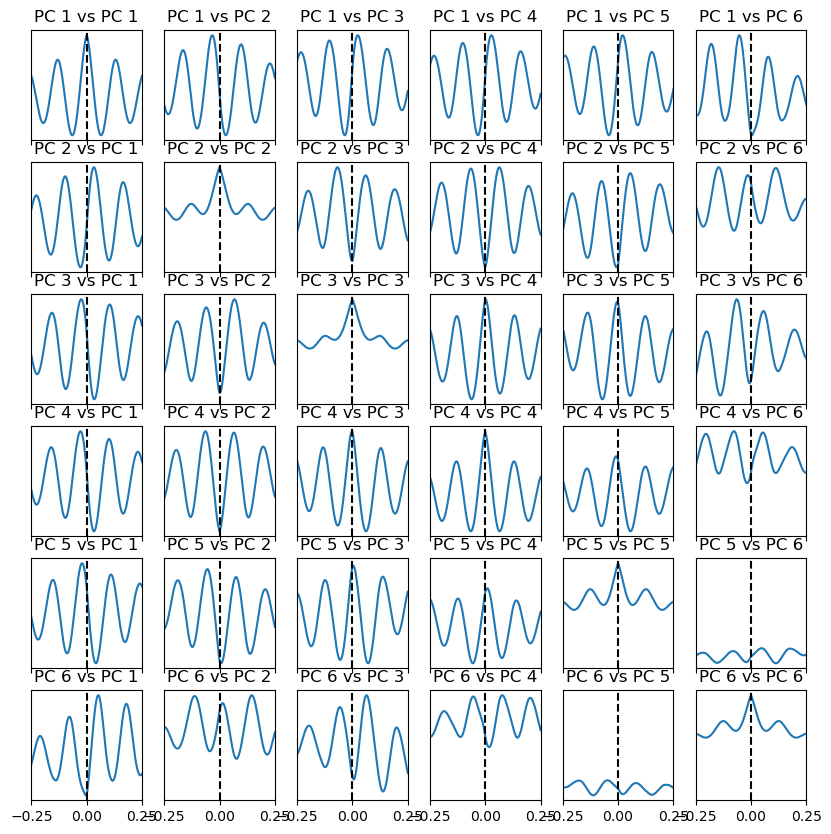

In [ ]:
n_plot = 6

fig, ax = plt.subplots(nrows=n_plot, ncols=n_plot, sharex=True, figsize=(10, 10))
for i in range(n_plot):
    for j in range(n_plot):
        ax[i, j].plot(lags, xcorrs[i, j, :])
        ax[i, j].set_title(f"PC {i+1} vs PC {j+1}")
        ax[i, j].axvline(0, c="k", ls="--")
        ax[i, j].set_yticks([])

plt.xlim(-0.25, 0.25)
# plt.xlim(-.5,.5)
# plt.xlim(-1,1)

Text(0, 0.5, 'Cross-covariance')

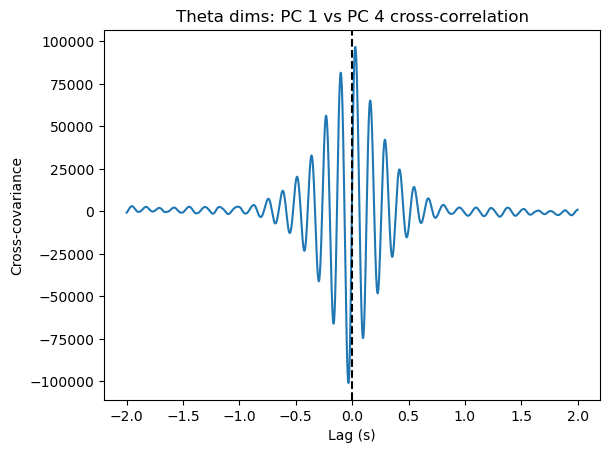

In [ ]:
# Theta phase xcorrelations
dims = [0, 3]

plt.plot(lags, xcorrs[dims[0], dims[1], :])
plt.title(f"Theta dims: PC {dims[0]+1} vs PC {dims[1]+1} cross-correlation")
plt.axvline(0, c="k", ls="--")
# plt.xlim(-.5,.5)

plt.xlabel("Lag (s)")
plt.ylabel("Cross-covariance")

Text(0, 0.5, 'Cross-covariance')

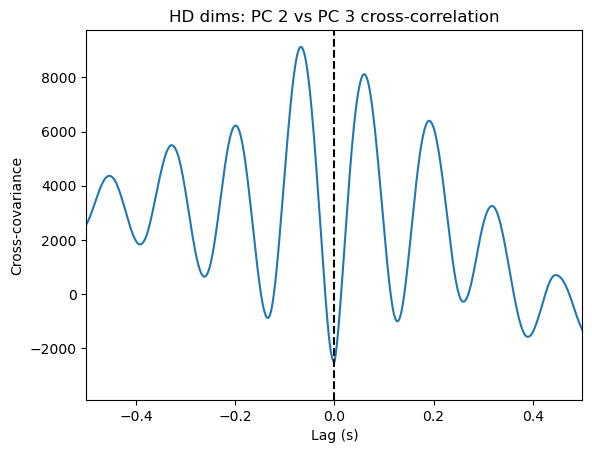

In [362]:
# head_dir xcorrelations
dims = [1, 2]

plt.plot(lags, xcorrs[dims[0], dims[1], :])
plt.title(f"HD dims: PC {dims[0]+1} vs PC {dims[1]+1} cross-correlation")
plt.axvline(0, c="k", ls="--")
plt.xlim(-0.5, 0.5)
# plt.xlim(-1,1)

plt.xlabel("Lag (s)")
plt.ylabel("Cross-covariance")

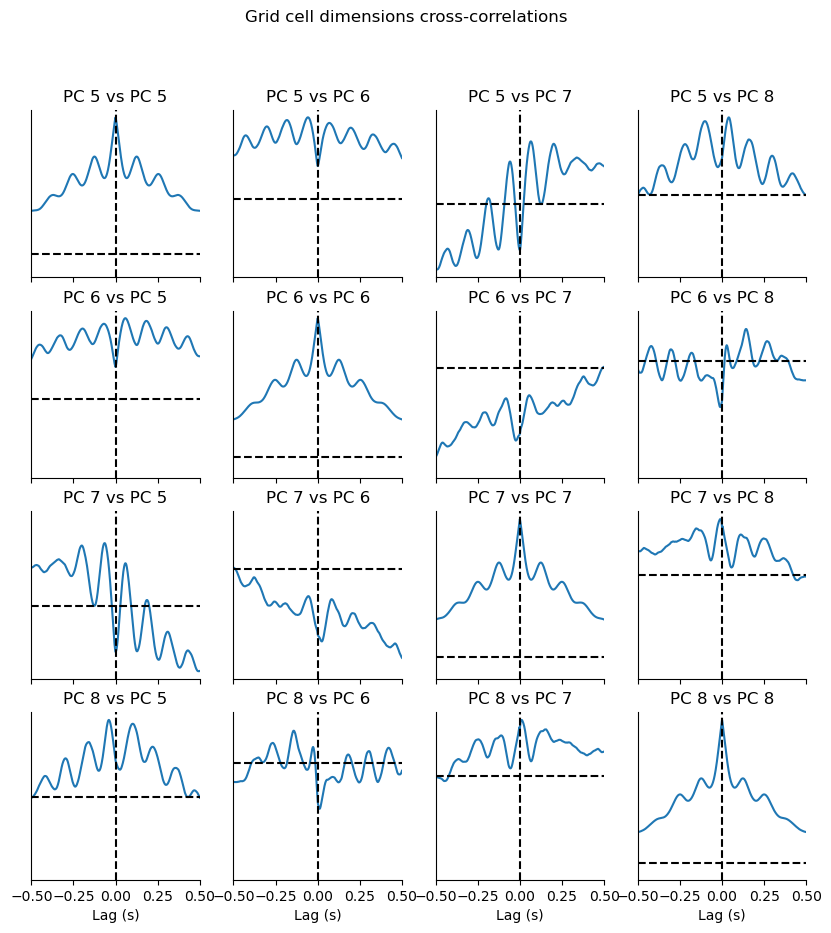

In [ ]:
# grid cell xcorrs
zoom = 0.5
dims = [4, 5, 6, 7]
fig, ax = plt.subplots(nrows=len(dims), ncols=len(dims), sharex=True, figsize=(10, 10))
for i in range(len(dims)):
    for j in range(len(dims)):
        ax[i, j].plot(lags, xcorrs[dims[i], dims[j], :])
        ax[i, j].set_title(f"PC {dims[i]+1} vs PC {dims[j]+1}")
        ax[i, j].axvline(0, c="k", ls="--")
        ax[i, j].axhline(0, c="k", ls="--")
        ax[i, j].set_yticks([])
        ax[i, j].spines[["right", "top"]].set_visible(False)

for a in ax[-1, :]:
    a.set_xlabel("Lag (s)")
if zoom:
    plt.xlim(-zoom, zoom)
fig.suptitle("Grid cell dimensions cross-correlations")

fig.savefig(
    figure_folder / f"context_grid_cell_xcorrs{'' if not zoom else f'_zoom{zoom}'}.svg"
)

### Similarity matrix of neuron embeddings

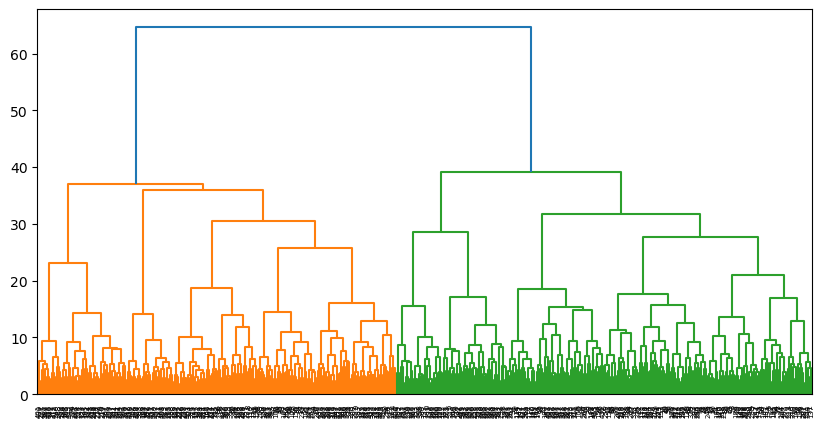

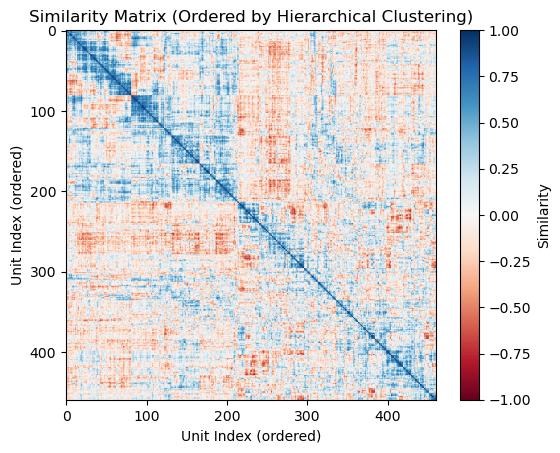

In [36]:
params = analysis.params
embed_matrix = params["params"]["embedding"]["encoder"]["encoder_matrix"]

# embed_matrix = params["params"]["rate_prediction"]["W_0"]
# embed_matrix = analysis.pca.transform(embed_matrix)

embed_matrix = embed_matrix / np.linalg.norm(embed_matrix, axis=1, keepdims=True)
sim = embed_matrix @ embed_matrix.T

# plt.imshow(sim, cmap="RdBu", vmin=-1, vmax=1)
# plt.colorbar()

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import leaves_list
from sklearn.cluster import SpectralClustering

# Perform hierarchical clustering on the similarity matrix
linked = linkage(sim, method="ward")
order = leaves_list(linked)

# Plot dendrogram
# plt.figure(figsize=(10, 5))
fig, ax = plt.subplots(
    nrows=1,
    height_ratios=[
        1,
    ],
    figsize=(10, 5),
    sharex=True,
)
dendrogram(linked, ax=ax)
# ax[0].set_title("Hierarchical Clustering Dendrogram")
# ax[0].set_xlabel("Unit Index")
# ax[0].set_ylabel("Distance")

# plt.figure(figsize=(8, 8))
# order = np.squeeze(np.argsort(np.squeeze(unit_cluster_id)))
c_rng = 1
fig = plt.figure()
plt.imshow(sim[order][:, order], aspect=1, cmap="RdBu", clim=(-c_rng, c_rng))
plt.title("Similarity Matrix (Ordered by Hierarchical Clustering)")
plt.xlabel("Unit Index (ordered)")
plt.ylabel("Unit Index (ordered)")
plt.colorbar(label="Similarity")
plt.show()

### Movie

1292it [13:56,  1.54it/s]


KeyboardInterrupt: 

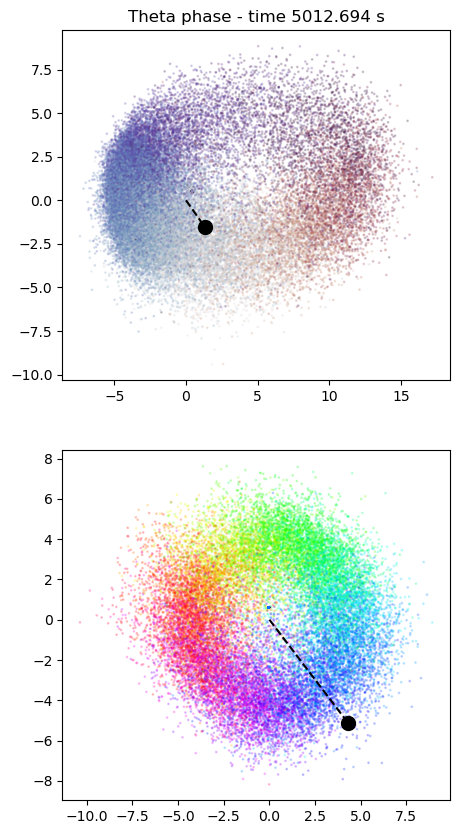

In [ ]:
output_dir = "/home/sambray/Documents/c3po/results/mec_embedding_vid"
os.makedirs(output_dir, exist_ok=True)
fig, ax = plt.subplots(nrows=2, height_ratios=[1, 1], figsize=(5, 10))


from tqdm import tqdm

theta_ax = ax[0]
hd_ax = ax[1]


theta_dims = [0, 3]
subset = slice(None, None, 30)
ind_phase = np.digitize(analysis.t, t)
theta_ax.scatter(
    c_pca[subset][:, theta_dims[0]],
    c_pca[subset][:, theta_dims[1]],
    s=1,
    alpha=0.2,
    c=thetaphase[ind_phase[subset]],
    cmap="twilight",
    rasterized=True,
)


hd_dims = [1, 2]
subset = slice(None, None, 50)
ind_dir = np.digitize(analysis.t, t)
# ind_data = ind_data[subset]
hd_ax.scatter(
    c_pca[subset][:, hd_dims[0]],
    c_pca[subset][:, hd_dims[1]],
    s=1,
    alpha=0.2,
    c=head_dir[ind_phase[subset]],
    cmap="hsv",
    rasterized=True,
)


for interval in valid_intervals:
    if interval[0] < 5000:
        continue
    if interval[1] - interval[0] > 1:
        break


i = np.digitize(interval[0] + 0, analysis.t)
scatter_ = []
lines_ = []
for ax, dims in zip([theta_ax, hd_ax], [theta_dims, hd_dims]):
    scatter_.append(
        ax.scatter(analysis.c_pca[i, dims[0]], analysis.c_pca[i, dims[1]], c="k", s=100)
    )
    lines_.append(
        ax.plot(
            [0, analysis.c_pca[i, dims[0]]],
            [0, analysis.c_pca[i, dims[1]]],
            c="k",
            ls="--",
        )
    )


t_plot = np.arange(interval[0], interval[1], 0.002)
for idx, t_i in tqdm(enumerate(t_plot)):
    theta_ax.set_title(f"Theta phase - time {t_i:.3f} s")
    i = np.digitize(t_i, analysis.t_interp)
    for j, dims in enumerate([theta_dims, hd_dims]):
        scatter_[j].set_offsets(
            [analysis.c_pca_interp[i, dims[0]], analysis.c_pca[i, dims[1]]]
        )
        lines_[j][0].set_data(
            [0, analysis.c_pca_interp[i, dims[0]]], [0, analysis.c_pca[i, dims[1]]]
        )
    fig.savefig(os.path.join(output_dir, f"frame_{idx:04d}.png"))

# Head Direction Decoding

## Demo

In [ ]:
t_feature = t
feature = head_dir[:, None]

# analysis.initialize_decoder(
#     model_type="knn",
#     n_neighbors=30,
#     weights="uniform",
#     # weights="distance",
#     metric="cosine",
# )
analysis.initialize_decoder(
    "discretized_regression",
    n_bins=100,
    max_iter=1000,
    balance_groups=True,
    multidim=False,
    predict_method="weighted_angle",
)


analysis.fit_decoder(
    feature,
    t_feature,
    intervals=valid_intervals,
    pca=True,
    # decode_dim=slice(1, 2),
    interpolate=True,
    smooth_context=1,
)

-3.141565 3.141478
(130000, 1) (130000, 16)
-3.141565 3.141478


/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
for interval in valid_intervals:
    if interval[0] < 5000:
        continue
    if interval[1] - interval[0] > 1:
        break

t_pred, feature_pred = analysis.predict_decoder(
    interval,
    interpolate=True,
    smooth_context=1,
)

Text(0.5, 0, 'Time (s)')

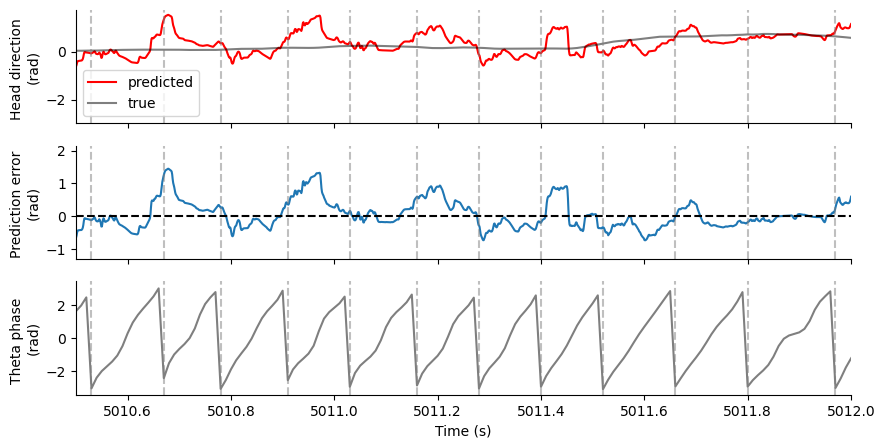

In [25]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(10, 5))


pred_ax = ax[0]
err_ax = ax[1]
theta_ax = ax[2]

pred_ax.plot(t_pred, feature_pred, c="r", label="predicted")
feature_ind = np.logical_and(t_feature >= interval[0], t_feature <= interval[1])
xx = t_feature[feature_ind]
yy = feature[feature_ind]
pred_ax.plot(xx, yy, c="k", alpha=0.5, label="true")
pred_ax.legend()

ind_map = np.digitize(t_pred, t_feature)
error = feature_pred - feature[ind_map]
err_ax.plot(t_pred, error)
err_ax.axhline(0, c="k", ls="--")

theta_ax.plot(t_feature[feature_ind], thetaphase[feature_ind], c="k", alpha=0.5)


delta_theta = np.diff(thetaphase[feature_ind], prepend=0)
ind_mark = np.where(np.abs(delta_theta) > np.pi)[0]
for im in ind_mark:
    for a in ax:
        a.axvline(t_feature[feature_ind][im], c="gray", ls="--", alpha=0.5)

for a in ax:
    a.spines[["right", "top"]].set_visible(False)

plt.xlim(5010.5, 5012)

pred_ax.set_ylabel("Head direction \n(rad)")
err_ax.set_ylabel("Prediction error \n(rad)")
theta_ax.set_ylabel("Theta phase \n(rad)")
plt.xlabel("Time (s)")

# fig.savefig(figure_folder / "head_direction_decoding_example.svg")

## 5-fold cross validated

In [ ]:
t_feature.shape, t_pred.shape

t_pred.size / t_feature.size

20.460361538461537

In [ ]:
t_feature = t
feature = head_dir[:, None]

# analysis.initialize_decoder(
#     model_type="knn",
#     n_neighbors=30,
#     weights="uniform",
#     # weights="distance",
#     metric="cosine",
# )
analysis.initialize_decoder(
    "discretized_regression",
    n_bins=100,
    max_iter=1000,
    balance_groups=True,
    multidim=False,
    predict_method="weighted_angle",
)


t_pred_list, feature_pred_list = analysis.cross_validated_decoding(
    feature,
    t_feature,
    intervals=valid_intervals,
    # pca=True,
    # decode_dim=slice(1, 2),
    interpolate=True,
    # smooth_context=1,
)
t_pred = np.concatenate(t_pred_list)
feature_pred = np.concatenate(feature_pred_list)

hd_t_pred = t_pred
hd_pred = feature_pred[:, 0]

Cross-validating decoder:   0%|          | 0/5 [00:00<?, ?it/s]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-3.141565 3.141478
(100372, 1) (100372, 16)
-3.141565 3.141478


Cross-validating decoder:  20%|██        | 1/5 [00:24<01:36, 24.06s/it]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-3.141565 3.141478
(107448, 1) (107448, 16)
-3.141565 3.141478


Cross-validating decoder:  40%|████      | 2/5 [00:51<01:18, 26.27s/it]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

Cross-validating decoder:  60%|██████    | 3/5 [01:24<00:57, 28.96s/it]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-3.141565 3.141478
(105752, 1) (105752, 16)
-3.141565 3.141478


Cross-validating decoder:  80%|████████  | 4/5 [01:49<00:27, 27.70s/it]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-3.141539 3.141478
(109149, 1) (109149, 16)
-3.141539 3.141478


Cross-validating decoder: 100%|██████████| 5/5 [02:16<00:00, 27.22s/it]


In [50]:
ind_map = np.digitize(t_pred, t_feature)
error = np.angle(np.exp(1j * (feature_pred - feature[ind_map])))
hd_error = np.angle(np.exp(1j * (hd_pred - feature[ind_map, 0])))

# error = np.zeros((t_pred.size,2))
# error[:, 0] = np.squeeze(feature_pred - feature[ind_map])

# feature_rolled = (feature[ind_map] + 2*np.pi) % (2 * np.pi) - np.pi
# feature_pred_rolled = (feature_pred + 2*np.pi) % (2 * np.pi) - np.pi
# error[:, 1] = np.squeeze(feature_pred_rolled - feature_rolled)

# error = error[:, np.argmin(np.abs(error).mean(axis=0))]

Text(0.5, 0, 'Time (s)')

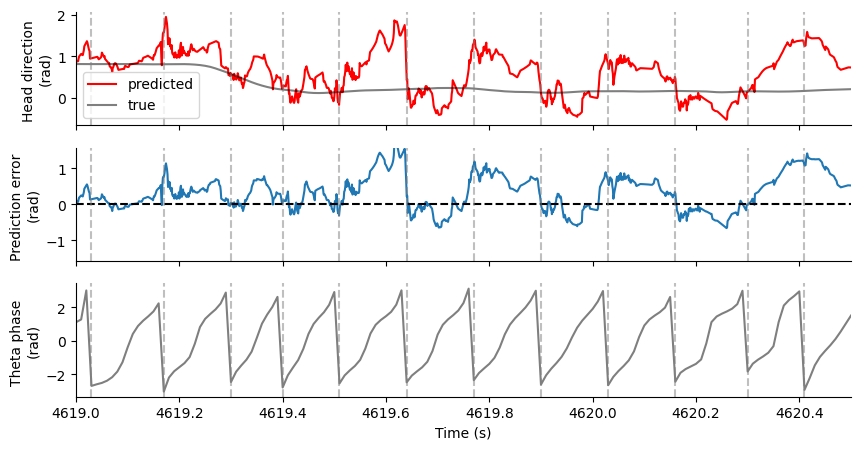

In [51]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(10, 5))

t_rng = 5000.5, 5002

# t_rng = t_pred.min(), t_pred.min()+100

t_rng = 4619, 4620.5

pred_ax = ax[0]
err_ax = ax[1]
theta_ax = ax[2]

ind_pred = np.logical_and(t_pred >= t_rng[0], t_pred <= t_rng[1])
pred_ax.plot(t_pred[ind_pred], feature_pred[ind_pred], c="r", label="predicted")
feature_ind = np.logical_and(t_feature >= t_rng[0], t_feature <= t_rng[1])
xx = t_feature[feature_ind]
yy = feature[feature_ind]
pred_ax.plot(xx, yy, c="k", alpha=0.5, label="true")
pred_ax.legend()

# ind_map = np.digitize(t_pred, t_feature)
# error = feature_pred - feature[ind_map]
err_ax.plot(t_pred[ind_pred], error[ind_pred])
err_ax.axhline(0, c="k", ls="--")
err_ax.set_ylim(-np.pi / 2, np.pi / 2)

theta_ax.plot(t_feature[feature_ind], thetaphase[feature_ind], c="k", alpha=0.5)


delta_theta = np.diff(thetaphase[feature_ind], prepend=0)
ind_mark = np.where(np.abs(delta_theta) > np.pi)[0]
for im in ind_mark:
    for a in ax:
        a.axvline(t_feature[feature_ind][im], c="gray", ls="--", alpha=0.5)

for a in ax:
    a.spines[["right", "top"]].set_visible(False)

plt.xlim(*t_rng)

pred_ax.set_ylabel("Head direction \n(rad)")
err_ax.set_ylabel("Prediction error \n(rad)")
theta_ax.set_ylabel("Theta phase \n(rad)")
plt.xlabel("Time (s)")

# fig.savefig(figure_folder / "head_direction_decoding_example.svg")

In [29]:
window_size = 4  # seconds

window_error = int(window_size / np.mean(np.diff(t_pred)))
window_feature = int(window_size / np.mean(np.diff(t_feature)))
nfft = 100


source_y = feature_pred
source_y = np.exp(1j * source_y)
f_decode, mid_decode, lo_decode, hi_decode = analysis.power_spectrum(
    intervals=valid_intervals,
    window_size=window_error,
    nfft=nfft * window_error,
    sourced_data=(t_pred, source_y),
)

ind_map = np.digitize(t_pred, t_feature)
error = np.exp(1j * (feature_pred - feature[ind_map]))
# error = feature_pred - feature[ind_map]
f, mid, lo, hi = analysis.power_spectrum(
    intervals=valid_intervals,
    window_size=window_error,
    nfft=nfft * window_error,
    sourced_data=(t_pred, error),
)


source_y = feature
source_y = np.exp(1j * source_y)
f_feature, mid_feature, lo_feature, hi_feature = analysis.power_spectrum(
    intervals=valid_intervals,
    window_size=window_feature,
    nfft=nfft * window_feature,
    sourced_data=(t_feature, source_y),
)

/home/sambray/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


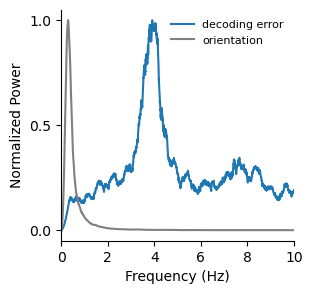

In [31]:
fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111)


plot_mid = mid[0]
plot_f = f.copy()
plot_mid = plot_mid * plot_f
plot_mid = plot_mid / np.max(plot_mid)
ind = plot_f >= 0
plot_mid = plot_mid[ind]
plot_f = plot_f[ind]
plt.plot(plot_f, plot_mid, label="decoding error")

# plot_mid = mid_decode[0]
# plot_f = f_decode.copy()
# plot_mid = plot_mid * plot_f
# plot_mid = plot_mid / np.max(plot_mid)
# plt.plot(plot_f, plot_mid, label="decode orientation")

plot_mid = mid_feature[0]
plot_f = f_feature.copy()
plot_mid = plot_mid * plot_f
plot_mid = plot_mid / np.max(plot_mid)
ind = plot_f >= 0
plot_mid = plot_mid[ind]
plot_f = plot_f[ind]
plt.plot(plot_f, plot_mid, label="orientation", color="grey")

# plt.xscale('log')

plt.xlim(0, 10)
# plt.xticks([0,10,20])
plt.yticks([0, 0.5, 1])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.legend(fontsize=8, frameon=False)
ax.spines[["right", "top"]].set_visible(False)

fig.savefig(figure_folder / "head_direction_decoding_error_spectrum.svg")

# Position Decoding

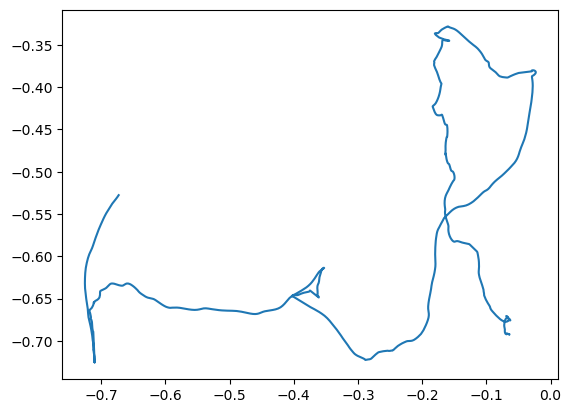

In [9]:
plt.plot(x[:1000], y[:1000])

In [38]:
t_feature[0]

valid_intervals[30][0]

4727.15

In [36]:
t_feature = t
feature = np.concatenate([x[:, None], y[:, None]], axis=1)
analysis.initialize_decoder(
    model_type="knn",
    n_neighbors=2,
    # weights="uniform",
    weights="distance",
    # metric="cosine",
    metric="l2",
)
# analysis.initialize_decoder(
#     "discretized_regression",
#     n_bins=100,
#     max_iter=100,
#     balance_groups=True,
#     multidim=True,
# )


analysis.fit_decoder(
    feature,
    t_feature,
    intervals=valid_intervals[30:],
    pca=True,
    # decode_dim=slice(4,16),
    interpolate=True,
    smooth_context=30,
    # balance_features=True,
    # balance_features_bins=50
)

[autoreload of spyglass.common.common_device failed: Traceback (most recent call last):
  File "/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):
  File "/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/sambray/ma

IndexError: arrays used as indices must be of integer (or boolean) type

In [ ]:
ii = 0
for interval in tqdm(valid_intervals):
    if interval[0] < 5000:
        continue
    if interval[1] - interval[0] > 1:
        if ii > 0:
            break
        ii += 1
print("HI")
t_pred, feature_pred = analysis.predict_decoder(
    interval, interpolate=True, smooth_context=3
)

  0%|          | 1/255 [00:00<00:00, 15252.01it/s]

HI


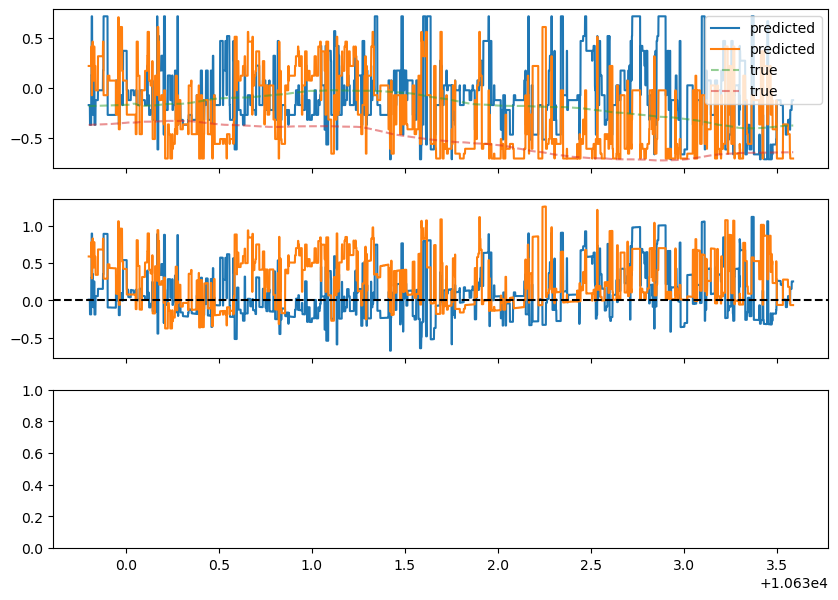

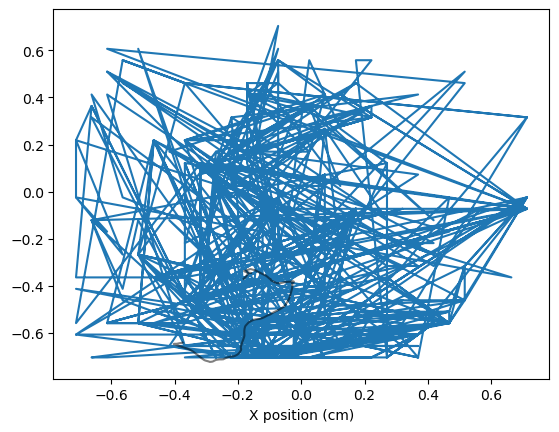

In [150]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(10, 7))
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)

pred_ax = ax[0]
err_ax = ax[1]
theta_ax = ax[2]

pred_ax.plot(t_pred, feature_pred, label="predicted")
feature_ind = np.logical_and(t_feature >= interval[0], t_feature <= interval[1])
xx = t_feature[feature_ind]
yy = feature[feature_ind]
pred_ax.plot(xx, yy, alpha=0.5, label="true", ls="--")
pred_ax.legend()

ax2.plot(feature_pred[:, 0], feature_pred[:, 1], label="predicted")
ax2.plot(yy[:, 0], yy[:, 1], c="k", alpha=0.5, label="true")
ax2.set_xlabel("X position (cm)")

ind_map = np.digitize(t_pred, t_feature)
error = feature_pred - feature[ind_map]
err_ax.plot(t_pred, error)
err_ax.axhline(0, c="k", ls="--")

# theta_ax.plot(t_feature[feature_ind], thetaphase[feature_ind], c="k", alpha=0.5)


# delta_theta = np.diff(thetaphase[feature_ind], prepend=0)
# ind_mark = np.where(np.abs(delta_theta) > np.pi)[0]
# for im in ind_mark:
#     for a in ax:
#         a.axvline(t_feature[feature_ind][im], c="gray", ls="--", alpha=0.5)

# plt.xlim(5010.5, 5012)

# pred_ax.set_ylabel("Head direction (rad)")
# err_ax.set_ylabel("Prediction error (rad)")
# theta_ax.set_ylabel("Theta phase (rad)")
# plt.xlabel("Time (s)")

# Neuron Embedding_analysis

## Head directio: Neuron embedding

In [7]:
W = analysis.params["params"]["embedding"]["encoder"]["encoder_matrix"]
W = W @ analysis.pca.components_.T


t_feature = t.copy()
feature = head_dir.copy()
c_feature_dims = [1, 2]

# t_feature = t.copy()
# feature = thetaphase
# c_feature_dims = [0,3]


t_spike_feature_ind = np.digitize(t_spikes, t_feature)
t_spike_feature = feature[t_spike_feature_ind - 1]

feature_bins = np.linspace(-np.pi, np.pi, 50)
feature_tuning_curves = []

for i in tqdm(range(feature_bins.size - 1)):
    bin_ind = np.where(
        (t_spike_feature >= feature_bins[i]) & (t_spike_feature < feature_bins[i + 1])
    )[0]
    # spike_counts = np.zeros(W.shape[0])
    # for bi in bin_ind:
    #     spike_counts += rates[bi]
    # feature_tuning_curves.append(spike_counts / len(bin_ind))
    spike_counts = rates[bin_ind].mean(axis=0)
    feature_tuning_curves.append(spike_counts)

feature_tuning_curves = np.array(feature_tuning_curves)

100%|██████████| 49/49 [00:02<00:00, 17.46it/s]


In [16]:
# c_feature_dims = [15,13]

W_feature = W[:, c_feature_dims]

W_angles = np.arctan2(W_feature[:, 1], W_feature[:, 0])
W_mag = np.linalg.norm(W_feature, 2, axis=1)

W_angles.shape, W_feature.shape

((460,), (460, 2))

/tmp/ipykernel_3398184/555406059.py:42: RuntimeWarning: divide by zero encountered in divide
  tuning_strength = np.max(feature_tuning_curves, axis=0) / np.median(


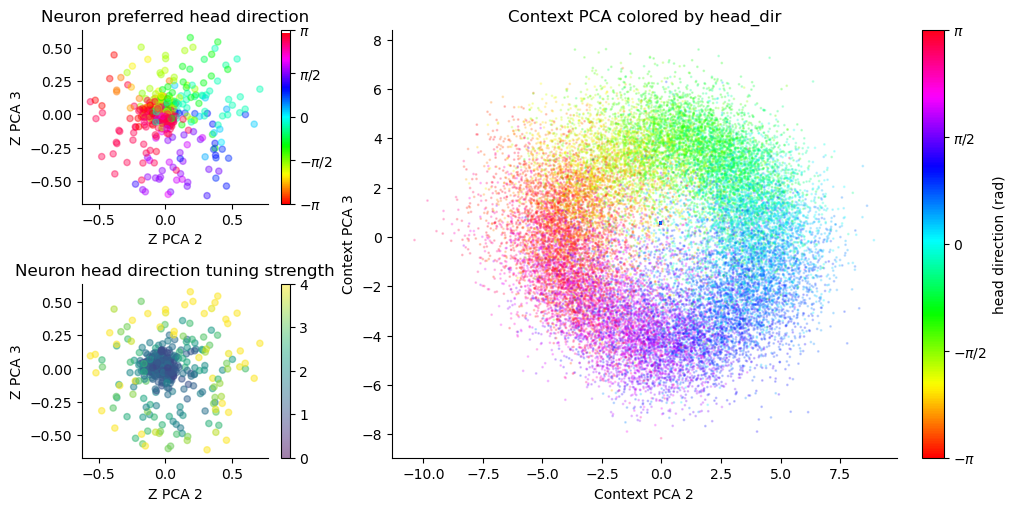

In [10]:
# fig, ax = plt.subplots(ncols=3, figsize=(10,3), sharex = True, sharey=True)
# fig = plt.figure(figsize=(8,4))
# ax = []
# ax.append(fig.add_subplot(2, 2, 1))
# ax.append(fig.add_subplot(2, 2, 3))
# ax.append(fig.add_subplot(1,2,2))

from matplotlib.gridspec import GridSpec
from src.c3po.toy_model_generators.phase import gaussian

fig = plt.figure(constrained_layout=True, figsize=(10, 5))
gs = GridSpec(2, 3, figure=fig)
tuning_ax = fig.add_subplot(gs[0, 0])
strength_ax = fig.add_subplot(gs[1, 0])
context_ax = fig.add_subplot(gs[:, 1:])

# Neuron tuning color
a = tuning_ax
color = np.argmax(feature_tuning_curves, axis=0)
color = feature_bins[:-1][color]
sc = a.scatter(
    W_feature[:, 0],
    W_feature[:, 1],
    c=color,
    edgecolor=None,
    cmap="hsv",
    alpha=0.4,
    s=20,
    rasterized=True,
)
cbar = plt.colorbar(
    sc,
    ax=a,
)
cbar.solids.set_alpha(1)
cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
a.set_title("Neuron preferred head direction")

# Neuron tuning strength color
a = strength_ax
tuning_strength = np.max(feature_tuning_curves, axis=0) / np.median(
    feature_tuning_curves, axis=0
)
tuning_strength = np.log2(tuning_strength)
sc = a.scatter(
    W_feature[:, 0],
    W_feature[:, 1],
    c=tuning_strength,
    edgecolor=None,
    cmap="viridis",
    alpha=0.5,
    clim=(0, 4),
    s=20,
    rasterized=True,
)
cbar = plt.colorbar(
    sc,
    ax=a,
)
# cbar.set_label('Tuning strength (spikes/s)')
a.set_title("Neuron head direction tuning strength")


# context embedding
subset = slice(None, None, 50)
ind_dir = np.digitize(analysis.t, t)
# ind_data = ind_data[subset]
sc = plt.scatter(
    c_pca[subset][:, c_feature_dims[0]],
    c_pca[subset][:, c_feature_dims[1]],
    s=1,
    alpha=0.2,
    c=head_dir[ind_dir[subset] - 1],
    cmap="hsv",
    rasterized=True,
)
cbar = plt.colorbar(label="head direction (rad)")
cbar.solids.set_alpha(1)
cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
plt.xlabel(f"Context PCA {c_feature_dims[0]+1}")
plt.ylabel(f"Context PCA {c_feature_dims[1]+1}")
plt.title("Context PCA colored by head_dir")

for a in [
    tuning_ax,
    strength_ax,
]:
    a.set_aspect("equal", "box")
    a.set_xlabel(f"Z PCA {c_feature_dims[0]+1}")
    a.set_ylabel(f"Z PCA {c_feature_dims[1]+1}")

for a in [tuning_ax, strength_ax, context_ax]:
    a.spines[["top", "right"]].set_visible(False)

# fig.savefig(figure_folder / "Z_embedding_head_direction.svg")

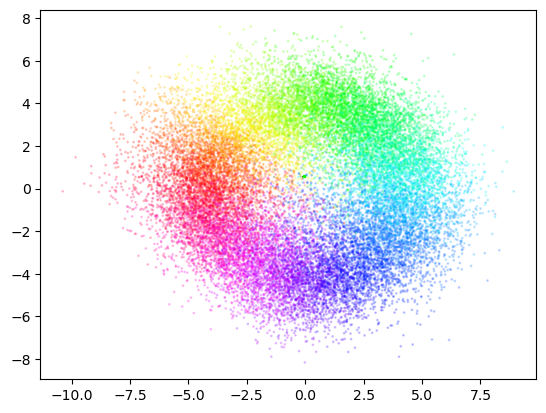

In [52]:
# context embedding
subset = slice(None, None, 50)
ind_dir = np.digitize(analysis.t, t_pred)
# ind_data = ind_data[subset]
sc = plt.scatter(
    c_pca[subset][:, c_feature_dims[0]],
    c_pca[subset][:, c_feature_dims[1]],
    s=1,
    alpha=0.2,
    c=hd_pred[ind_dir[subset] - 1],
    cmap="hsv",
    rasterized=True,
)

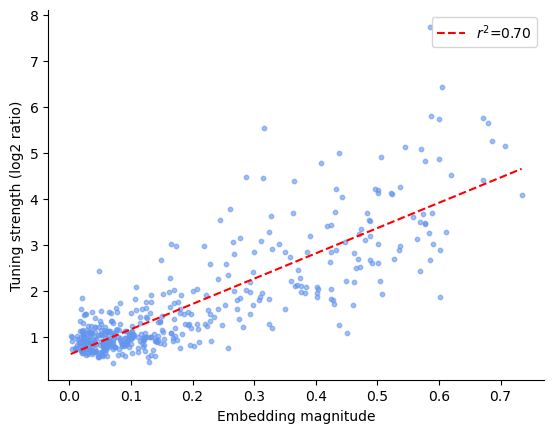

In [ ]:
fig = plt.figure()

tuning_strength = np.max(feature_tuning_curves, axis=0) / np.median(
    feature_tuning_curves, axis=0
)
tuning_strength = np.log2(tuning_strength)

plt.scatter(
    W_mag, tuning_strength, color="cornflowerblue", alpha=0.6, s=10, rasterized=True
)

plt.xlabel("Embedding magnitude")
plt.ylabel("Tuning strength (log2 ratio)")

from scipy.stats import linregress

ind = np.isfinite(W_mag) & np.isfinite(tuning_strength)
slope, intercept, r_value, p_value, std_err = linregress(
    W_mag[ind], tuning_strength[ind]
)
x_fit = np.array([W_mag.min(), W_mag.max()])
y_fit = intercept + slope * x_fit
plt.plot(x_fit, y_fit, c="r", ls="--", label=f"$r^2$={r_value**2:.2f}")
plt.legend()

ax = fig.gca()
ax.spines[["top", "right"]].set_visible(False)
# fig.savefig(figure_folder / "hd_embedding_magnitude_vs_tuning_strength.svg")

/tmp/ipykernel_3398184/3929628017.py:29: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(


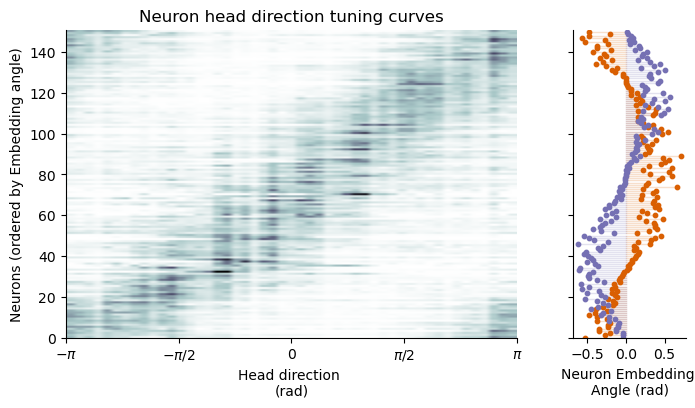

In [24]:
fig, ax = plt.subplots(ncols=2, sharey=True, figsize=(8, 4), width_ratios=[4, 1])

ind_include = W_mag > 0.2

feature_tuning_curves.shape

# spike_order = np.argsort(np.argmax(feature_tuning_curves, axis=0))
spike_order = np.argsort(W_angles[ind_include])


plot_curves = feature_tuning_curves[:, ind_include][:, spike_order].T.copy()
plot_curves = plot_curves / np.mean(plot_curves, axis=1, keepdims=True)
ax[0].imshow(
    plot_curves,
    aspect="auto",
    extent=(feature_bins[0], feature_bins[-1], 0, plot_curves.shape[0]),
    cmap="bone_r",
)

# ax[1].scatter(
#     W_angles[ind_include][spike_order],
#     np.arange(np.sum(ind_include)),
#     c="k",
#     s=5,
# )
for i,pc in enumerate(c_feature_dims):
    color = plt.cm.Dark2((pc) / 8)
    vals = W_feature[:, i][ind_include][spike_order]
    ax[1].scatter(
        vals,
        np.arange(np.sum(ind_include)),
        c=color,
        s=10,
        label=f"PC {pc+1}",
    )
    for j,v in enumerate(vals):
        ax[1].plot(
            [v,0],
            [j, j],
            c=color,
            alpha=0.2,
            lw=1,
            zorder=-4
        )


ax[0].set_xlabel("Head direction \n(rad)")
ax[0].set_ylabel("Neurons (ordered by Embedding angle)")

ax[1].set_xlabel("Neuron Embedding \nAngle (rad)")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
ax[0].set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
ax[0].set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

# ax[1].set_xticks([-np.pi, 0, np.pi])
# ax[1].set_xticklabels([r"$-\pi$", "0", r"$\pi$"])

ax[0].set_title("Neuron head direction tuning curves")
fig.savefig(figure_folder / "hd_tuning_curves_ordered_by_embedding_angle.svg")

In [39]:
t_feature = t.copy()
feature = head_dir.copy()
c_feature_dims = [1, 2]

# t_feature = t.copy()
# feature = thetaphase
# c_feature_dims = [0,3]


t_spike_feature_ind = np.digitize(t_spikes, t_feature)
t_spike_feature = feature[t_spike_feature_ind - 1]

t_spike_gain_int = np.digitize(t_spikes, analysis.t)
t_spike_gain = hd_gain[t_spike_gain_int - 1]

valid_spikes = np.logical_and(t_spikes >= analysis.t[0], t_spikes <= analysis.t[-1])

feature_bins = np.linspace(-np.pi, np.pi, 30)
feature_tuning_curves = []

for i in tqdm(range(feature_bins.size - 1)):
    bin_ind = np.where(
        (t_spike_feature >= feature_bins[i])
        & (t_spike_feature < feature_bins[i + 1])
        & valid_spikes
    )[0]
    # spike_counts = np.zeros(W.shape[0])
    # for bi in bin_ind:
    #     spike_counts += rates[bi]
    # feature_tuning_curves.append(spike_counts / len(bin_ind))
    spike_counts = rates[bin_ind].mean(axis=0)
    feature_tuning_curves.append(spike_counts)

feature_tuning_curves = np.array(feature_tuning_curves)

feature_tuning_curves_lo_gain = []
feature_tuning_curves_hi_gain = []
lo_thresh = np.percentile(hd_gain, 20)
hi_thresh = np.percentile(hd_gain, 80)

for i in tqdm(range(feature_bins.size - 1)):
    bin_ind = np.where(
        (t_spike_feature >= feature_bins[i])
        & (t_spike_feature < feature_bins[i + 1])
        & valid_spikes
        & (t_spike_gain >= hi_thresh)
    )[0]
    spike_counts = rates[bin_ind].mean(axis=0)
    feature_tuning_curves_hi_gain.append(spike_counts)
feature_tuning_curves_hi_gain = np.array(feature_tuning_curves_hi_gain)

for i in tqdm(range(feature_bins.size - 1)):
    bin_ind = np.where(
        (t_spike_feature >= feature_bins[i])
        & (t_spike_feature < feature_bins[i + 1])
        & valid_spikes
        & (t_spike_gain < lo_thresh)
    )[0]
    spike_counts = rates[bin_ind].mean(axis=0)
    feature_tuning_curves_lo_gain.append(spike_counts)
feature_tuning_curves_lo_gain = np.array(feature_tuning_curves_lo_gain)

100%|██████████| 29/29 [00:00<00:00, 50.30it/s]


Text(0.5, 0.98, 'Neuron head direction tuning curves')

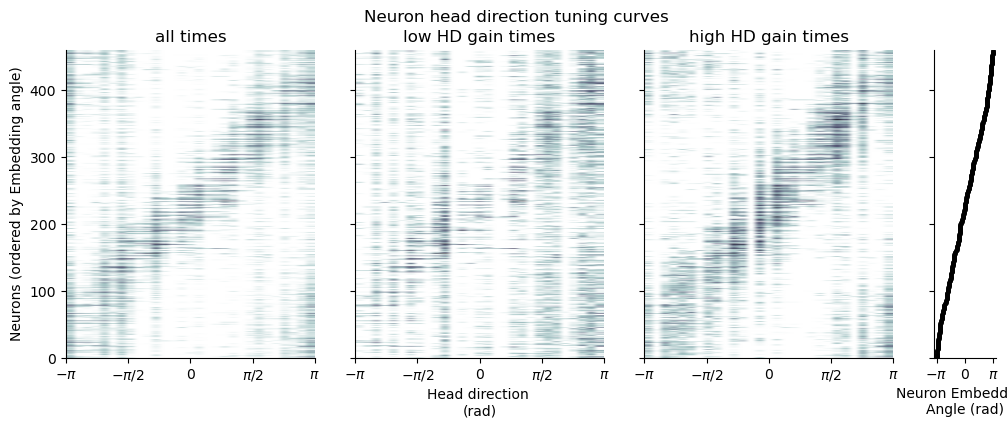

In [40]:
fig, ax = plt.subplots(ncols=4, sharey=True, figsize=(12, 4), width_ratios=[4, 4, 4, 1])

ind_include = W_mag > 0.0

feature_tuning_curves.shape

# spike_order = np.argsort(np.argmax(feature_tuning_curves, axis=0))
spike_order = np.argsort(W_angles[ind_include])

norm_curves = None
for i, curves in enumerate(
    [
        feature_tuning_curves,
        feature_tuning_curves_lo_gain,
        feature_tuning_curves_hi_gain,
    ]
    #  [feature_tuning_curves_hi_gain, feature_tuning_curves_lo_gain, feature_tuning_curves_hi_gain]
):
    plot_curves = curves[:, ind_include][:, spike_order].T.copy()
    if norm_curves is None:
        norm_curves = np.mean(plot_curves, axis=1, keepdims=True)
    norm_curves = np.mean(plot_curves, axis=1, keepdims=True)
    plot_curves = plot_curves / norm_curves
    plot_curves = np.log2(plot_curves + 1e-3)
    ax[i].imshow(
        plot_curves,
        aspect="auto",
        extent=(feature_bins[0], feature_bins[-1], 0, plot_curves.shape[0]),
        cmap="bone_r",
        clim=(0, 4),
        # cmap ="RdBu",
        # clim =(-6,6)
    )

ax[-1].scatter(
    W_angles[ind_include][spike_order],
    np.arange(np.sum(ind_include)),
    c="k",
    s=5,
)


ax[1].set_xlabel("Head direction \n(rad)")
ax[0].set_ylabel("Neurons (ordered by Embedding angle)")

ax[-1].set_xlabel("Neuron Embedding \nAngle (rad)")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)

for a in ax[:-1]:
    a.set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
    a.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

ax[-1].set_xticks([-np.pi, 0, np.pi])
ax[-1].set_xticklabels([r"$-\pi$", "0", r"$\pi$"])

ax[0].set_title("all times")
ax[1].set_title("low HD gain times")
ax[2].set_title("high HD gain times")

fig.suptitle("Neuron head direction tuning curves")
# fig.savefig(figure_folder / "hd_tuning_curves_ordered_by_embedding_angle.svg")

In [84]:
moser_hd_decode = Dsession["lmt"][0][0][0][0][0]["id"][0][0]["XA"][0][0].flatten()
moser_hd_error = np.angle(np.exp(1j * (moser_hd_decode - head_dir)))
moser_hd_decode.shape, t.shape

((130000,), (130000,))

Text(0.5, 0, 'Time (s)')

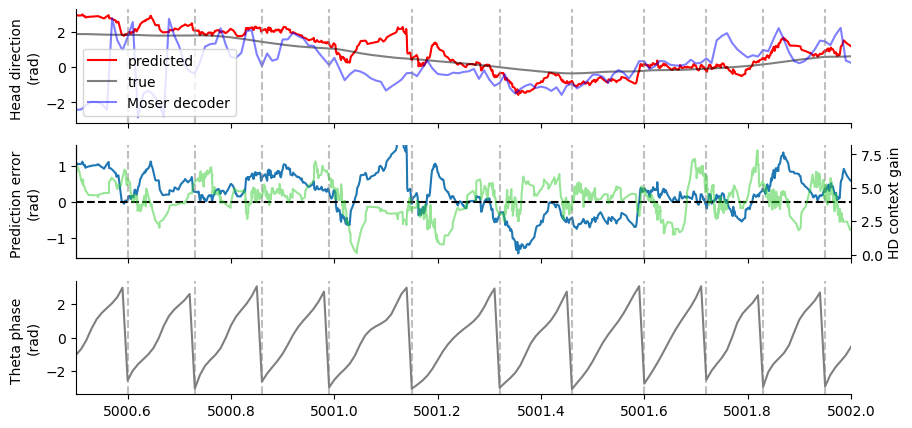

In [ ]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(10, 5))

t_rng = 5000.5, 5002

# t_rng = t_pred.min(), t_pred.min()+100

# t_rng = 4619, 4620.5

# t_rng = 4640, 4643.5
# t_rng = 4619, 4620.5

pred_ax = ax[0]
err_ax = ax[1]
theta_ax = ax[2]

ind_pred = np.logical_and(t_pred >= t_rng[0], t_pred <= t_rng[1])
pred_ax.plot(t_pred[ind_pred], feature_pred[ind_pred], c="r", label="predicted")
feature_ind = np.logical_and(t_feature >= t_rng[0], t_feature <= t_rng[1])
xx = t_feature[feature_ind]
yy = feature[feature_ind]
pred_ax.plot(xx, yy, c="k", alpha=0.5, label="true")
moser_ind = np.logical_and(t >= t_rng[0], t <= t_rng[1])
pred_ax.plot(
    t[moser_ind], moser_hd_decode[moser_ind], c="b", alpha=0.5, label="Moser decoder"
)

pred_ax.legend()


# ang_vel_ax = pred_ax.twinx()
# ang_vel_ax.set_ylabel("Angular velocity \n(rad/s)")
# ind_ang_vel = np.logical_and(t >= t_rng[0], t <= t_rng[1])
# # ang_vel_ax.plot(t[ind_ang_vel], np.abs(ang_vel[ind_ang_vel]), c="b", alpha=0.5)
# ang_vel_ax.plot(t[ind_ang_vel], (ang_vel[ind_ang_vel]), c="b", alpha=0.5)

# ind_map = np.digitize(t_pred, t_feature)
# error = feature_pred - feature[ind_map]
err_ax.plot(t_pred[ind_pred], error[ind_pred])
err_ax.axhline(0, c="k", ls="--")
err_ax.set_ylim(-np.pi / 2, np.pi / 2)

ind_gain = np.logical_and(analysis.t >= t_rng[0], analysis.t <= t_rng[1])
gain_plot = hd_gain[ind_gain]
# gain_plot = gain_plot - np.mean(gain_plot)
# gain_plot = gain_plot / np.max(gain_plot)
gain_ax = err_ax.twinx()
gain_ax.set_ylabel("HD context gain")
gain_ax.plot(analysis.t[ind_gain], gain_plot, c="limegreen", alpha=0.5)


theta_ax.plot(t_feature[feature_ind], thetaphase[feature_ind], c="k", alpha=0.5)


delta_theta = np.diff(thetaphase[feature_ind], prepend=0)
ind_mark = np.where(np.abs(delta_theta) > np.pi)[0]
for im in ind_mark:
    for a in ax:
        a.axvline(t_feature[feature_ind][im], c="gray", ls="--", alpha=0.5)


for a in ax:
    a.spines[["right", "top"]].set_visible(False)
gain_ax.spines["top"].set_visible(False)

plt.xlim(*t_rng)

pred_ax.set_ylabel("Head direction \n(rad)")
err_ax.set_ylabel("Prediction error \n(rad)")
theta_ax.set_ylabel("Theta phase \n(rad)")
plt.xlabel("Time (s)")

# fig.savefig(figure_folder / "head_direction_decoding_example.svg")

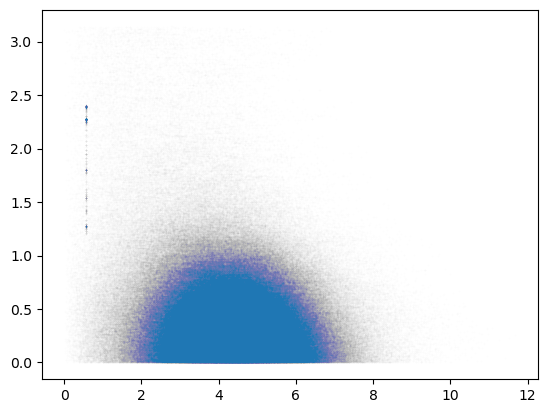

In [ ]:
# plt.scatter
# plt.scatter(hd_gain, np.abs(ang_vel[ind_match]), alpha=0.002, s=5)
from src.c3po.analysis.analysis import interval_list_contains_ind

ind = interval_list_contains_ind(
    no_gap_intervals,
    analysis.t,
)
ind_match = np.digitize(analysis.t[ind], t_pred) - 1
hd_gain.shape, hd_pred.shape
plt.scatter(hd_gain[ind], np.abs(hd_error[ind_match]), alpha=0.002, s=1)

In [73]:
analysis.bin_context_by_feature?

Signature:
analysis.bin_context_by_feature(
    feature: numpy.ndarray,
    feature_times: numpy.ndarray,
    bins=None,
    valid_intervals=None,
    pca=False,
    interpolated=False,
    alt_data=None,
    projection_name=None,
)
Docstring:
Bin the context by co-occurring feature values

Args:
    feature (np.ndarray): Feature values. Shape (n_samples,).
    feature_times (np.ndarray): Times of the feature values. Shape (n_samples,).
    bins (int, optional): Number of bins to use. Defaults to None.
    valid_intervals (np.ndarray, optional): Intervals to consider. Defaults to None.
    alt_data (np.ndarray, optional): Alternative data to bin instead of context. Defaults to None.
File:      ~/Documents/c3po/src/c3po/analysis/analysis.py
Type:      method

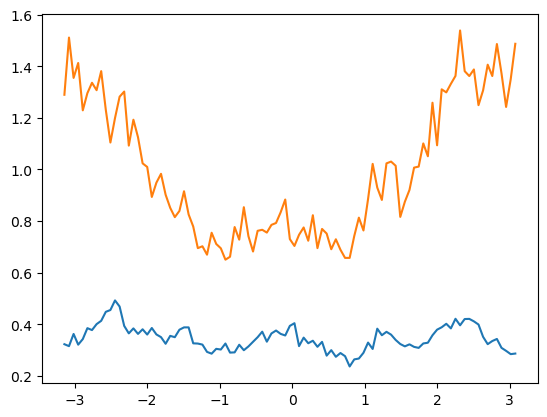

In [ ]:
results, bins = analysis.bin_context_by_feature(
    feature=head_dir,
    feature_times=t,
    valid_intervals=no_gap_intervals,
    alt_data=(t_pred, np.abs(hd_error)),
    bins=100,
)
mid = [np.median(r) for r in results]
lo = [np.percentile(r, 25) for r in results]
hi = [np.percentile(r, 75) for r in results]
plt.plot(bins[:-1], mid)

results, bins = analysis.bin_context_by_feature(
    feature=head_dir,
    feature_times=t,
    valid_intervals=no_gap_intervals,
    alt_data=(t, np.abs(moser_hd_error)),
    bins=100,
)
mid = [np.median(r) for r in results]
lo = [np.percentile(r, 25) for r in results]
hi = [np.percentile(r, 75) for r in results]
plt.plot(bins[:-1], mid)

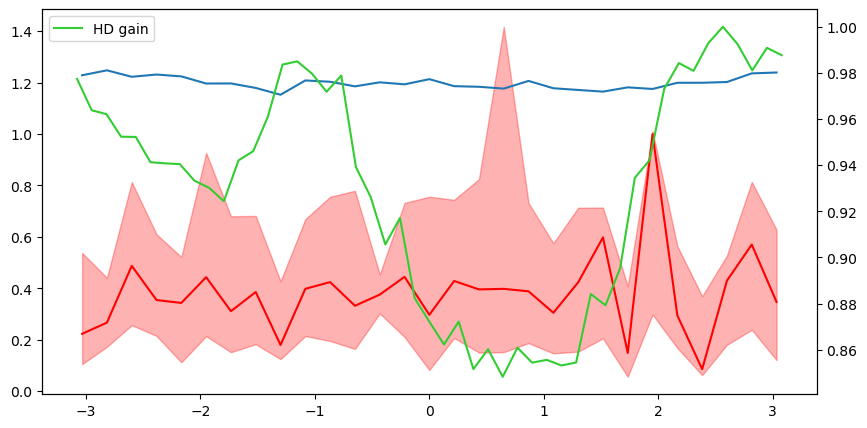

In [ ]:
gain_theta_ind = np.digitize(analysis.t, t)
gain_theta = thetaphase[gain_theta_ind - 1]
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)

gain_ax = ax.twinx()
bins = np.linspace(-np.pi, np.pi, 50)
vals = []
for i in range(len(bins) - 1):
    ind = np.where((gain_theta >= bins[i]) & (gain_theta < bins[i + 1]))[0]
    vals.append(hd_gain[ind].mean())
gain_ax.plot(
    (bins[:-1] + bins[1:]) / 2, vals / np.max(vals), c="limegreen", label="HD gain"
)


error_theta_ind = np.digitize(t_pred, t)
error_theta = thetaphase[error_theta_ind - 1]
bins = np.linspace(-np.pi, np.pi, 30)
vals = []
lo = []
hi = []
for i in range(len(bins) - 1):
    ind = np.where((error_theta >= bins[i]) & (error_theta < bins[i + 1]))[0]
    xx = np.abs(hd_error[ind])
    # xx = error[ind]
    # xx = xx[xx < np.pi ]
    vals.append(np.median(xx))
    lo.append(np.percentile(xx, 25))
    hi.append(np.percentile(xx, 75))
ax.plot((bins[:-1] + bins[1:]) / 2, vals / np.max(vals), label="Decoding error", c="r")
ax.fill_between(
    (bins[:-1] + bins[1:]) / 2,
    np.array(lo) / np.max(vals),
    np.array(hi) / np.max(vals),
    color="r",
    alpha=0.3,
)


bins = np.linspace(-np.pi, np.pi, 30)
vals = []
for i in range(len(bins) - 1):
    ind = np.where((thetaphase >= bins[i]) & (thetaphase < bins[i + 1]))[0]
    xx = ang_vel[ind]
    xx = np.abs(xx)
    # xx =xx[xx<3]

    # xx = np.log(xx + 1e-8)
    # xx = xx[xx < np.pi / 2]
    vals.append(np.mean(xx))
ax.plot(
    (bins[:-1] + bins[1:]) / 2,
    vals,
    label="Angular velocity",
)
plt.legend()

## Theta phase embedding

In [71]:
W = analysis.params["params"]["embedding"]["encoder"]["encoder_matrix"]
W = W @ analysis.pca.components_.T


t_feature = t.copy()
feature = thetaphase.copy()
c_feature_dims = [0, 3]
# c_feature_dims = [4,5]
# t_feature = t.copy()
# feature = x


# t_feature = t.copy()
# feature = thetaphase
# c_feature_dims = [0,3]


t_spike_feature_ind = np.digitize(t_spikes, t_feature)
t_spike_feature = feature[t_spike_feature_ind - 1]

feature_bins = np.linspace(-np.pi, np.pi, 100)
feature_tuning_curves = []

for i in tqdm(range(feature_bins.size - 1)):
    bin_ind = np.where(
        (t_spike_feature >= feature_bins[i]) & (t_spike_feature < feature_bins[i + 1])
    )[0]
    # spike_counts = np.zeros(W.shape[0])
    # for bi in bin_ind:
    #     spike_counts += rates[bi]
    # feature_tuning_curves.append(spike_counts / len(bin_ind))
    spike_counts = rates[bin_ind].mean(axis=0)
    feature_tuning_curves.append(spike_counts)

feature_tuning_curves = np.array(feature_tuning_curves)

# c_feature_dims = [15,13]

W_feature = W[:, c_feature_dims]
W_angles = np.arctan2(W_feature[:, 0], W_feature[:, 1])
W_mag = np.linalg.norm(W_feature, 2, axis=1)
W_angles.shape

100%|██████████| 99/99 [00:02<00:00, 40.68it/s]


(460,)

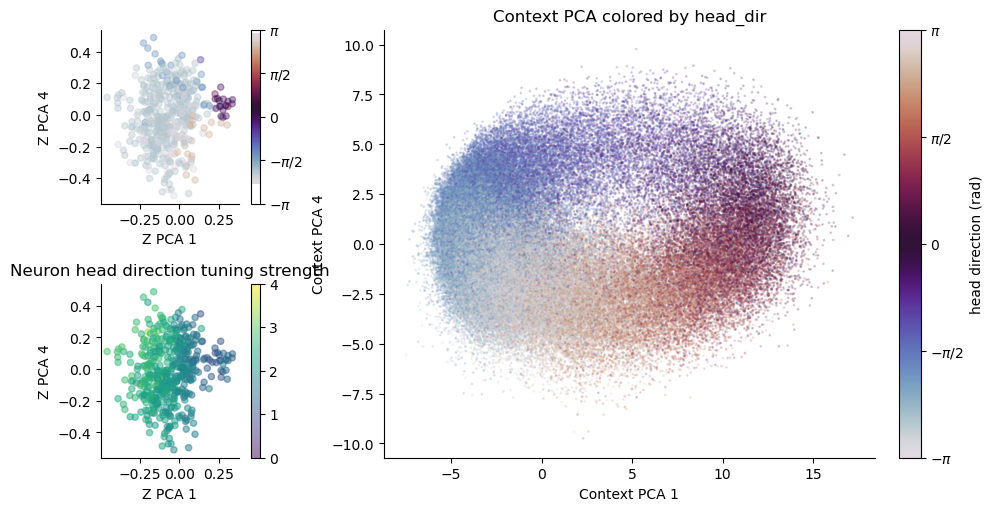

In [72]:
# fig, ax = plt.subplots(ncols=3, figsize=(10,3), sharex = True, sharey=True)
# fig = plt.figure(figsize=(8,4))
# ax = []
# ax.append(fig.add_subplot(2, 2, 1))
# ax.append(fig.add_subplot(2, 2, 3))
# ax.append(fig.add_subplot(1,2,2))

from matplotlib.gridspec import GridSpec
from src.c3po.toy_model_generators.phase import gaussian

fig = plt.figure(constrained_layout=True, figsize=(10, 5))
gs = GridSpec(2, 3, figure=fig)
tuning_ax = fig.add_subplot(gs[0, 0])
strength_ax = fig.add_subplot(gs[1, 0])
context_ax = fig.add_subplot(gs[:, 1:])

# Neuron tuning color
a = tuning_ax
color = np.argmax(feature_tuning_curves, axis=0)
color = feature_bins[:-1][color]
sc = a.scatter(
    W_feature[:, 0],
    W_feature[:, 1],
    c=color,
    edgecolor=None,
    cmap="twilight",
    alpha=0.4,
    s=20,
)
cbar = plt.colorbar(
    sc,
    ax=a,
)
cbar.solids.set_alpha(1)
cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
# a.set_title("Neuron preferred head direction")

# Neuron tuning strength color
a = strength_ax
tuning_strength = np.max(feature_tuning_curves, axis=0) / np.median(
    feature_tuning_curves, axis=0
)
tuning_strength = np.log2(tuning_strength)
sc = a.scatter(
    W_feature[:, 0],
    W_feature[:, 1],
    c=tuning_strength,
    edgecolor=None,
    cmap="viridis",
    alpha=0.5,
    clim=(0, 4),
    s=20,
)
cbar = plt.colorbar(
    sc,
    ax=a,
)
# cbar.set_label('Tuning strength (spikes/s)')
a.set_title("Neuron head direction tuning strength")


# context embedding
subset = slice(None, None, 10)
ind_dir = np.digitize(analysis.t, t)
# ind_data = ind_data[subset]
sc = plt.scatter(
    c_pca[subset][:, c_feature_dims[0]],
    c_pca[subset][:, c_feature_dims[1]],
    s=1,
    alpha=0.2,
    c=feature[ind_dir[subset] - 1],
    cmap="twilight",
    rasterized=True,
)
cbar = plt.colorbar(label="head direction (rad)")
cbar.solids.set_alpha(1)
cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
plt.xlabel(f"Context PCA {c_feature_dims[0]+1}")
plt.ylabel(f"Context PCA {c_feature_dims[1]+1}")
plt.title("Context PCA colored by head_dir")

for a in [
    tuning_ax,
    strength_ax,
]:
    a.set_aspect("equal", "box")
    a.set_xlabel(f"Z PCA {c_feature_dims[0]+1}")
    a.set_ylabel(f"Z PCA {c_feature_dims[1]+1}")

for a in [tuning_ax, strength_ax, context_ax]:
    a.spines[["top", "right"]].set_visible(False)

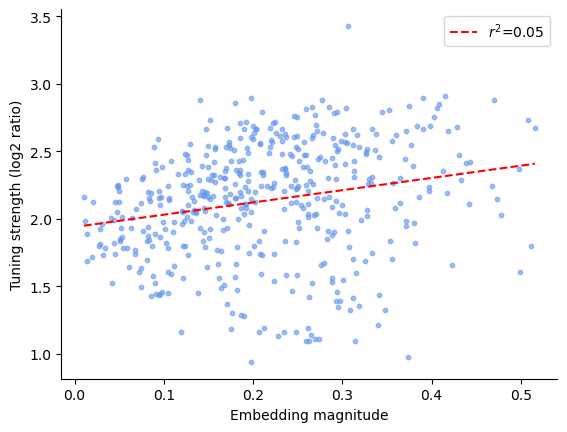

In [73]:
fig = plt.figure()

tuning_strength = np.max(feature_tuning_curves, axis=0) / np.median(
    feature_tuning_curves, axis=0
)
tuning_strength = np.log2(tuning_strength)

plt.scatter(W_mag, tuning_strength, color="cornflowerblue", alpha=0.6, s=10)

plt.xlabel("Embedding magnitude")
plt.ylabel("Tuning strength (log2 ratio)")

from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(W_mag, tuning_strength)
x_fit = np.array([W_mag.min(), W_mag.max()])
y_fit = intercept + slope * x_fit
plt.plot(x_fit, y_fit, c="r", ls="--", label=f"$r^2$={r_value**2:.2f}")
plt.legend()

ax = fig.gca()
ax.spines[["top", "right"]].set_visible(False)

Text(0.5, 1.0, 'Neuron head direction tuning curves')

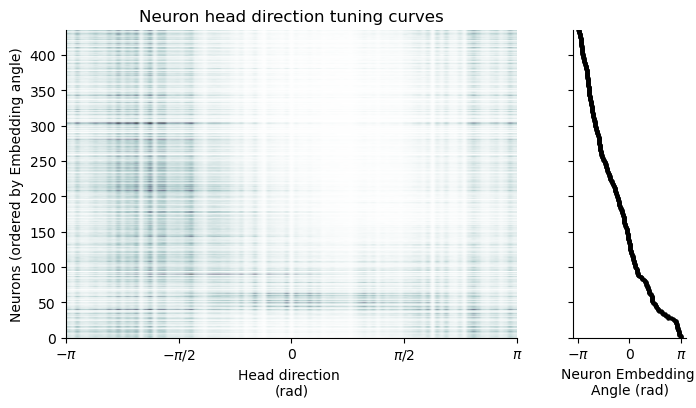

In [ ]:
fig, ax = plt.subplots(ncols=2, sharey=True, figsize=(8, 4), width_ratios=[4, 1])

ind_include = W_mag > 0.05
feature_tuning_curves.shape

# spike_order = np.argsort(np.argmax(feature_tuning_curves, axis=0))
spike_order = np.argsort(W_angles[ind_include])

plot_curves = feature_tuning_curves[:, ind_include][:, spike_order].T.copy()
# plot_curves = feature_tuning_curves[:, ind_include][:, spike_order].T.copy()
# plot_curves = plot_curves / np.mean(plot_curves, axis=1, keepdims=True)
ax[0].imshow(
    plot_curves,
    aspect="auto",
    extent=(feature_bins[0], feature_bins[-1], 0, plot_curves.shape[0]),
    cmap="bone_r",
)

ax[1].scatter(
    W_angles[ind_include][spike_order],
    np.sum(ind_include) - np.arange(np.sum(ind_include)),
    c="k",
    s=5,
)


ax[0].set_xlabel("Head direction \n(rad)")
ax[0].set_ylabel("Neurons (ordered by Embedding angle)")

ax[1].set_xlabel("Neuron Embedding \nAngle (rad)")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
ax[0].set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
ax[0].set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

ax[1].set_xticks([-np.pi, 0, np.pi])
ax[1].set_xticklabels([r"$-\pi$", "0", r"$\pi$"])

ax[0].set_title("Neuron head direction tuning curves")

In [77]:
plot_curves.shape, feature_tuning_curves.shape, W_angles.shape

((436, 99), (99, 460), (460,))

## Firing rate: null model embedding

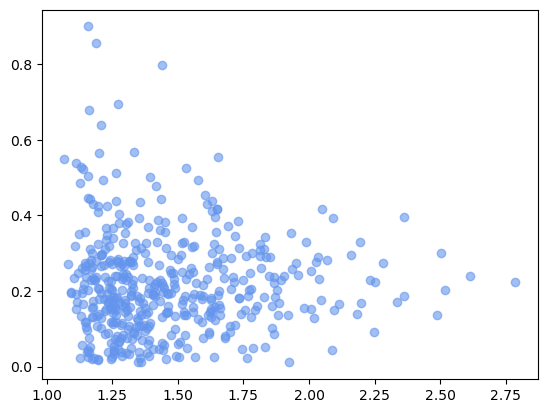

In [ ]:
from src.c3po.analysis.analysis import interval_list_contains_ind

W = analysis.params["params"]["embedding"]["encoder"]["encoder_matrix"]


# W_mag = np.linalg.norm(W, ord=2, axis=1)
W_mag = 1 * np.sum(W**2, axis=-1)
W_mag = np.exp(W_mag)

rates.shape, W_mag.shape
ind_rates = interval_list_contains_ind(
    valid_intervals,
    t_spikes,
)

mean_rate = rates.mean(axis=0)
# mean_rate = np.log(mean_rate)
# mean_rates = np.log(rates[ind_rates] + 1e-3).mean(axis=0)

plt.scatter(W_mag, mean_rate, color="cornflowerblue", alpha=0.6)

# Neuron  grid bases contribution

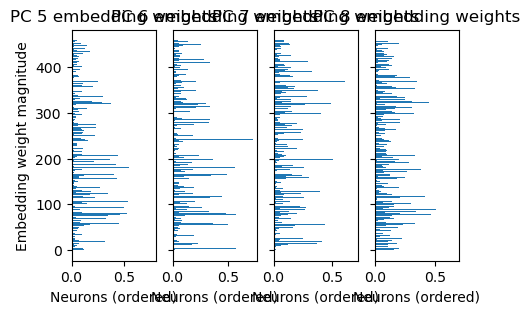

In [ ]:
dim = [4, 5, 6, 7]

W = analysis.params["params"]["embedding"]["encoder"]["encoder_matrix"]
W = W @ analysis.pca.components_.T

W = np.abs(W)

fig, ax = plt.subplots(ncols=len(dim), sharey=True, figsize=(5, 3))

ind = np.argsort(W[:, 1])

for i, d in enumerate(dim):
    ax[i].barh(np.arange(W.shape[0]), W[ind, d])
    ax[i].set_title(f"PC {d+1} embedding weights")
    ax[i].set_xlabel("Neurons (ordered)")
    if i == 0:
        ax[i].set_ylabel("Embedding weight magnitude")

# plt.scatter(W[:,6],W[:,5])

# W_mag = np.abs(W[:,dim])

# ind_order = np.argsort(W_mag)

# plt.plot(np.arange(W_mag.size), W_mag[ind_order])
# plt.bar(np.arange(W_mag.size), W_mag[ind_order])

In [244]:
np.max(W_mag)
W_mag.shape

(460,)

# Neuron basis decomposition

In [213]:
params = analysis.params
embed_matrix = np.array(params["params"]["embedding"]["encoder"]["encoder_matrix"])

pca_matrix = analysis.pca.components_

embed_matrix = embed_matrix @ pca_matrix.T

# W = params["params"]["rate_prediction"]["W_0"]
# embed_matrix = analysis.pca.transform(embed_matrix)

# embed_matrix = embed_matrix / np.linalg.norm(embed_matrix, axis=1, keepdims=True)
# sim = embed_matrix @ embed_matrix.T

# print(embed_matrix[0,0])
# neuron_order = np.argsort(-(np.abs(embed_matrix[:,:]).argmax(axis=1)))
# embed_matrix = embed_matrix[neuron_order]
# print(embed_matrix[0, 0])

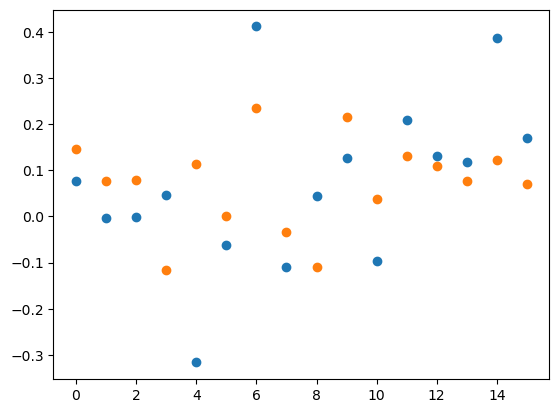

In [214]:
i = 1  # neuron to analyze


plt.scatter(np.arange(context_dim), embed_matrix[i])

i = 2  # neuron to analyze


plt.scatter(np.arange(context_dim), embed_matrix[i])

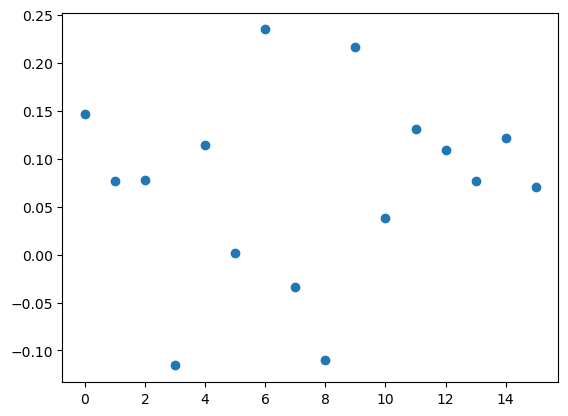

In [215]:
spike_id = 129
plt.scatter(np.arange(context_dim), embed_matrix[i])

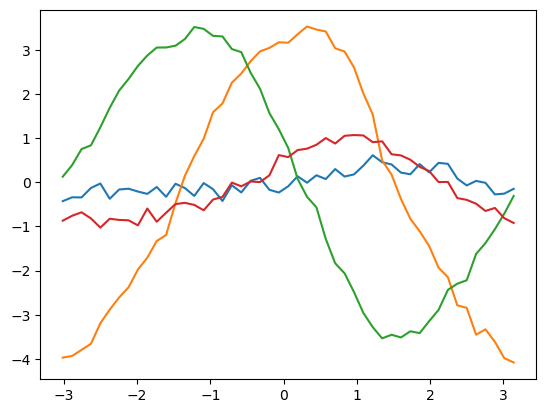

In [216]:
n_bins = 50
t_feature = t
feature = head_dir

context_binned, bins = analysis.bin_context_by_feature(
    feature, t_feature, bins=np.linspace(-np.pi, np.pi, n_bins), pca=True
)

c_feature_mean = np.array([np.mean(cb, axis=0) for cb in context_binned])

plt.plot(bins[1:], np.array(c_feature_mean)[:, :4])

# fig, ax = plt.subplots(nrows=9, sharex=True, figsize=(5, 12))
# for dat, loc in zip(context_binned, bins):
#     for i, a in enumerate(ax):
#         color = "cornflowerblue"
#         a.scatter(loc, np.median(dat[:, i]), c=color)

In [217]:
# rates_binned, bins = analysis.bin_context_by_feature(
#     feature, t_feature, bins=np.linspace(-np.pi, np.pi, n_bins),
#     alt_data=(t_spikes[::], rates[::, spike_id][:,None])
# )

# rates_feature_mean = np.array([np.mean(rb, axis=0) for rb in rates_binned])

# mua = rates.mean(axis=1)
# mua_binned, bins = analysis.bin_context_by_feature(
#     feature, t_feature, bins=np.linspace(-np.pi, np.pi, n_bins),
#     alt_data=(t_spikes[::], mua[:, None])
# )
# mua_feature_mean = np.array([np.mean(mb, axis=0) for mb in mua_binned])


mua = rates.mean(axis=1)
rel_rate = rates[:, spike_id] / mua
rel_rate_binned, bins = analysis.bin_context_by_feature(
    feature,
    t_feature,
    bins=np.linspace(-np.pi, np.pi, n_bins),
    alt_data=(t_spikes[::], rel_rate[:, None]),
)
rel_rate_feature_mean = np.array([np.nanmean(rb, axis=0) for rb in rel_rate_binned])

/tmp/ipykernel_3427287/1057777924.py:17: RuntimeWarning: invalid value encountered in divide
  rel_rate = rates[:, spike_id] / mua


array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 1.10535634,
        0.12662834],
       [0.        , 0.        , 0.        , ..., 0.        , 0.91284401,
        0.09357724],
       [0.        , 0.        , 0.        , ..., 0.        , 0.74461053,
        0.06830428]])

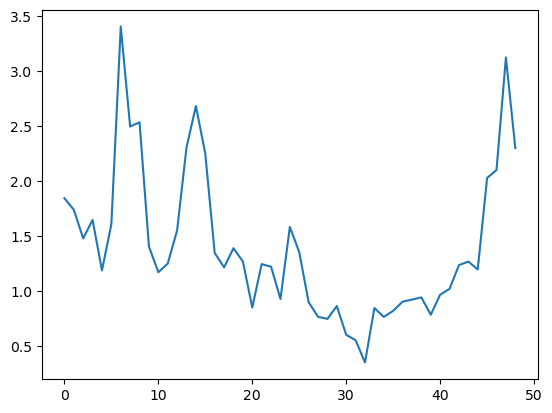

In [218]:
# plt.plot(rates_feature_mean)
# plt.plot(mua_feature_mean, c="k", lw=2)
plt.plot(rel_rate_feature_mean)
rates

In [219]:
plt.plot(rates_feature_mean)
plt.plot(mua_feature_mean, c="k", lw=2)
rates

NameError: name 'rates_feature_mean' is not defined

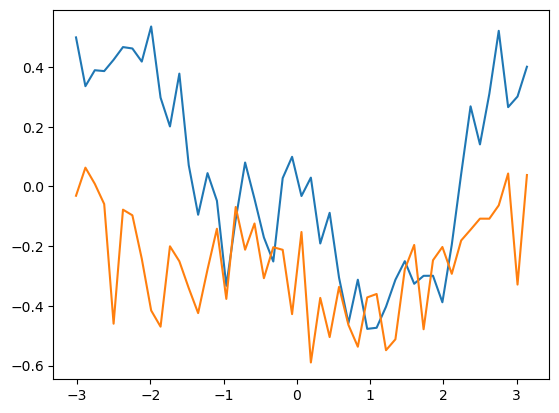

In [ ]:
c_feature_mean.shape, embed_matrix[spike_id].shape

predicted_field = c_feature_mean @ embed_matrix[spike_id]

empirical_field = rates_feature_mean
empirical_field = np.log(empirical_field / mua_feature_mean)
# empirical_field = np.log(rel_rate_feature_mean)

plt.plot(bins[1:], predicted_field)
plt.plot(bins[1:], empirical_field)

# Sensitivity/Specificity Analysis

In [ ]:
def discrete_entropy(dist):
    """Calculate the discrete entropy of a probability distribution."""
    dist = np.ravel(dist)
    return -np.sum(dist * np.log2(dist + 1e-10))


def mutual_information(p_x, p_y, p_xy):
    """Calculate the mutual information between two random variables."""
    p_x = np.ravel(p_x)
    p_y = np.ravel(p_y)
    p_xy = np.ravel(p_xy)
    return discrete_entropy(p_x) + discrete_entropy(p_y) - discrete_entropy(p_xy)


def _sensitivity(p_x, p_y, p_xy):
    """Calculate the sensitivity of y with respect to x."""
    p_x = np.ravel(p_x)
    p_y = np.ravel(p_y)
    p_xy = np.ravel(p_xy)
    return mutual_information(p_x, p_y, p_xy) / discrete_entropy(p_x)


def _specificity(p_x, p_y, p_xy):
    """Calculate the specificity of y with respect to x."""
    p_x = np.ravel(p_x)
    p_y = np.ravel(p_y)
    p_xy = np.ravel(p_xy)
    return mutual_information(p_x, p_y, p_xy) / discrete_entropy(p_y)


def invariance(p_x, p_y, p_n, p_xyn):
    """Calculate the invariance of y with respect to x."""
    return _specificity(p_x, p_y, p_xyn) - _specificity(p_x, p_n, p_xyn)


def analyze_representation(
    analysis,
    t_feature,
    feature,
    pc_set=None,
    c_bins=100,
    feature_bins=100,
    valid_intervals=None,
):
    t_data = analysis.t
    c_data = analysis.c_pca

    ind_feature = np.digitize(t_data, t_feature)
    aligned_feature = feature[ind_feature]
    if aligned_feature.ndim == 1:
        aligned_feature = aligned_feature[:, None]
    feature_bins = [
        np.linspace(
            np.min(aligned_feature[:, i]), np.max(aligned_feature[:, i]), feature_bins
        )
        for i in range(aligned_feature.shape[1])
    ]

    if isinstance(pc_set, int):
        pc_set = (pc_set,)
    ind_valid = (
        interval_list_contains_ind(valid_intervals, t_data)
        if valid_intervals is not None
        else np.ones(t_data.shape, dtype=bool)
    )
    aligned_feature = aligned_feature[ind_valid]
    c_data = c_data[ind_valid]
    c_bins = [
        np.linspace(np.min(c_data[:, i]), np.max(c_data[:, i]), c_bins) for i in pc_set
    ]

    full_data = np.concatenate([c_data[:, pc_set], aligned_feature], axis=1)
    p_joint = np.histogramdd(full_data, bins=c_bins + feature_bins)[0]
    p_joint = p_joint / np.sum(p_joint)

    # Calculate the marginal distributions
    p_context = np.sum(p_joint, axis=tuple(range(len(pc_set))))
    p_feature = np.sum(p_joint, axis=tuple(range(len(pc_set), len(p_joint.shape))))

    specificity = _specificity(p_feature, p_context, p_joint)
    sensitivity = _sensitivity(p_feature, p_context, p_joint)
    return specificity, sensitivity, p_joint

In [ ]:
t_feature = t.copy()
# feature_list = [head_dir, thetaphas]
feature_list = []
# feature = head_dir.copy()


# # feature = thetaphase.copy()
# feature = np.column_stack([x, y])
# # feature = y

feature_list.append(head_dir)
feature_list.append(thetaphase)
feature_list.append(np.column_stack([x, y]))

feature_names = ["head_dir", "thetaphase", "xy position"]

groups = [i for i in range(analysis.context_dim)]
groups = [i for i in range(8)]
groups.append((0, 3))
groups.append((1, 2))
groups.append((4, 5, 6, 7))
# groups.append((8,9,10,11))
# groups.append((12,13,14,15))

results = []
for feature in tqdm(feature_list):
    sensitivity = []
    specificity = []

    for i in groups:
        # print(f"Analyzing representation for PC set {i}")
        spec, sens, _ = analyze_representation(
            analysis, t_feature, feature, pc_set=i, c_bins=50, feature_bins=50
        )
        specificity.append(spec)
        sensitivity.append(sens)

    sensitivity = np.array(sensitivity)
    specificity = np.array(specificity)
    results.append((specificity, sensitivity))

100%|██████████| 3/3 [06:16<00:00, 125.42s/it]


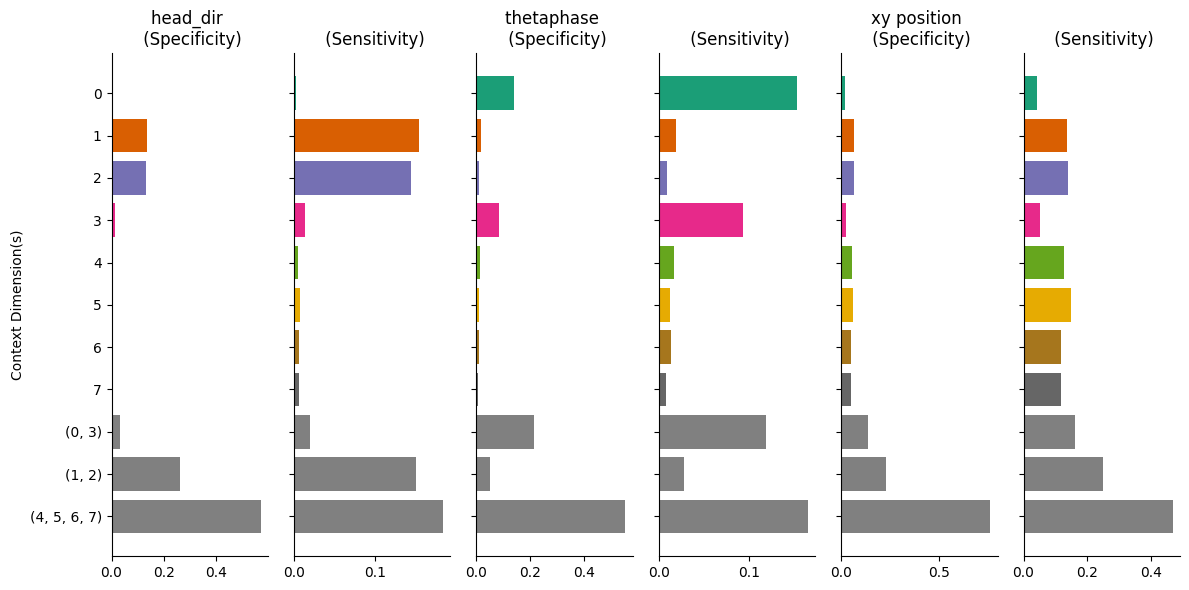

In [ ]:
# xx_labels = np.arange(len(specificity))
# xx = max(xx_labels) - xx_labels

xx = np.arange(len(groups))
xx = xx.max() - xx
xx_labels = groups

ind_single = [i for i in range(len(groups)) if isinstance(groups[i], int)]
ind_grouped = [i for i in range(len(groups)) if isinstance(groups[i], tuple)]
colors = ["blue", "red"]

fig, ax = plt.subplots(ncols=2 * len(results), sharey=True, figsize=(12, 6))


for i, (specificity, sensitivity) in enumerate(results):
    # for ind_set, color in zip([ind_single, ind_grouped], colors):
    #     ax[0 + 2*i].barh(xx[ind_set], specificity[ind_set], label='Specificity')
    #     ax[1 + 2*i].barh(xx[ind_set], sensitivity[ind_set], label='Sensitivity')
    for j in range(len(xx)):
        label = xx_labels[j]
        if isinstance(label, tuple):
            color = "grey"
        else:
            color = plt.cm.Dark2(label / 8)
        ax[2 * i].barh(xx[j], specificity[j], color=color)
        ax[1 + 2 * i].barh(xx[j], sensitivity[j], color=color)

    ax[2 * i].set_title(f"{feature_names[i]} \n (Specificity)")
    ax[1 + 2 * i].set_title(f"\n (Sensitivity)")

ax[0].set_yticks(xx, xx_labels)
ax[0].set_ylabel("Context Dimension(s)")


for a in ax:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [ ]:
def discrete_entropy(dist):
    """Calculate the discrete entropy of a probability distribution."""
    dist = np.ravel(dist)
    return -np.sum(dist * np.log2(dist + 1e-10))


def mutual_information(p_x, p_y, p_xy):
    """Calculate the mutual information between two random variables."""
    p_x = np.ravel(p_x)
    p_y = np.ravel(p_y)
    p_xy = np.ravel(p_xy)
    return discrete_entropy(p_x) + discrete_entropy(p_y) - discrete_entropy(p_xy)


def sensitivity(p_x, p_y, p_xy):
    """Calculate the sensitivity of y with respect to x."""
    p_x = np.ravel(p_x)
    p_y = np.ravel(p_y)
    p_xy = np.ravel(p_xy)
    return mutual_information(p_x, p_y, p_xy) / discrete_entropy(p_x)


def specificity(p_x, p_y, p_xy):
    """Calculate the specificity of y with respect to x."""
    p_x = np.ravel(p_x)
    p_y = np.ravel(p_y)
    p_xy = np.ravel(p_xy)
    return mutual_information(p_x, p_y, p_xy) / discrete_entropy(p_y)


# def dice_coefficient(p_x, p_y):
#     """Calculate the Dice coefficient between two sets."""
#     p_x = np.ravel(p_x)
#     p_y = np.ravel(p_y)
#     return 2 * np.sum(p_x * p_y) / (np.sum(p_x) + np.sum(p_y))

# dice_coefficient(p_feature, p_context)


sensitivity(p_feature, p_context, p_joint), specificity(p_feature, p_context, p_joint)

(0.03660699120214733, 0.016317058521834973)

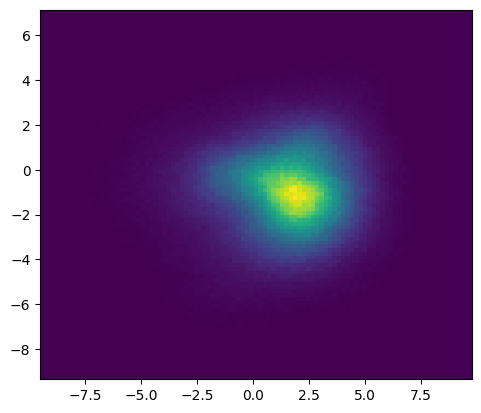

In [224]:
p_context = np.sum(p_joint, axis=-1)
p_context = p_context / np.sum(p_context)

plt.imshow(p_context, extent=[c_bins[0][0], c_bins[0][-1], c_bins[1][0], c_bins[1][-1]])

# plt.imshow(p_context.mean(axis=2))
# plt.colorbar()

In [ ]:
from src.c3po.analysis.analysis import interval_list_contains_ind

t_feature = t.copy()
feature = head_dir.copy()
# feature_bins = np.linspace(features.min(), features.max(), 10)


c_binned, feature_bins = analysis.bin_context_by_feature(
    feature, t_feature, pca=True, valid_intervals=valid_intervals, bins=100
)
c_all = np.concatenate(c_binned)

p_feature = np.histogram(feature, bins=feature_bins)[0]
p_feature = p_feature / np.sum(p_feature)

In [ ]:
i = 1
c_bins = np.linspace(np.min(c_all[:, i]), np.max(c_all[:, i]), 100)
p_context = np.histogram(c_all[:, i], bins=c_bins)[0]
p_context = p_context / np.sum(p_context)

p_feature_context = np.zeros((len(p_feature), len(p_context)))
for j, c in enumerate(c_binned):
    p_feature_context[j] = np.histogram(c[:, i], bins=c_bins)[0]
p_feature_context = p_feature_context / np.sum(p_feature_context)

In [ ]:
pc_set = (1, 2)


# c_bins = [np.linspace(np.min(c_all[:, i]), np.max(c_all[:, i]), 100) for i in pc_set]
p_context, c_bins = np.histogramdd(c_all[:, pc_set], bins=10)[0]
p_context = p_context / np.sum(p_context)

# p_feature_context = np.zeros((len(p_feature), len(p_context)))
# for j, c in enumerate(c_binned):
#     p_feature_context[j] = np.histogram(c[:,i], bins=c_bins)[0]
# p_feature_context = p_feature_context / np.sum(p_feature_context)

ValueError: too many values to unpack (expected 2)

In [149]:
r = np.histogramdd(c_all[:, pc_set], bins=(10, 10))[0]

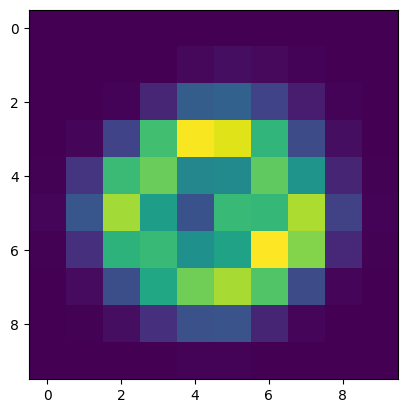

In [150]:
plt.imshow(r)

In [ ]:
def discrete_entropy(dist):
    """Calculate the discrete entropy of a probability distribution."""
    return -np.sum(dist * np.log2(dist + 1e-10))


def mutual_information(p_x, p_y, p_xy):
    """Calculate the mutual information between two random variables."""
    return discrete_entropy(p_x) + discrete_entropy(p_y) - discrete_entropy(p_xy)


def sensitivity(p_x, p_y, p_xy):
    """Calculate the sensitivity of y with respect to x."""
    return mutual_information(p_x, p_y, p_xy) / discrete_entropy(p_x)


sensitivity(p_feature, p_context, p_feature_context)
sensitivity(p_context, p_feature, p_feature_context)

0.17545007178565925

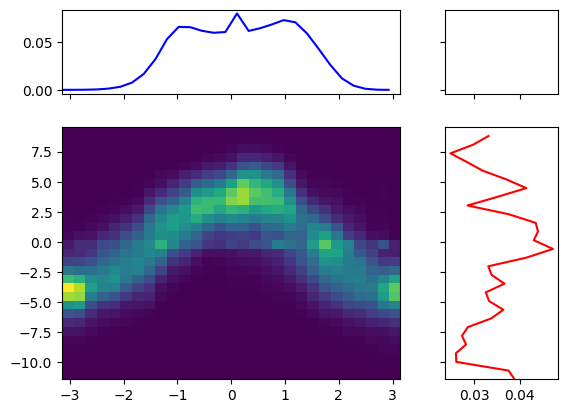

In [ ]:
# fig = plt.figure()
# gs = fig.add_gridspec(2, 2, width_ratios=[3, 1], height_ratios=[1, 3],)
# ax_joint = fig.add_subplot(gs[1, 0])
# ax_marg_x = fig.add_subplot(gs[0, 0])
# ax_marg_y = fig.add_subplot(gs[1, 1])

fig, ax = plt.subplots(
    2, 2, width_ratios=[3, 1], height_ratios=[1, 3], sharex="col", sharey="row"
)
ax_joint = ax[1, 0]
ax_feature = ax[0, 0]
ax_context = ax[1, 1]


ax_joint.imshow(
    p_feature_context.T,
    aspect="auto",
    origin="lower",
    extent=[feature_bins[0], feature_bins[-1], c_bins[0], c_bins[-1]],
)

ax_feature.plot(feature_bins[:-1], np.sum(p_feature_context, axis=0), color="blue")
ax_context.plot(np.sum(p_feature_context, axis=1), c_bins[:-1], color="red")